# EDA Section

## Midterm Report Submission

## Project Title

**Customer Value-Driven Inventory Forecasting in E-Commerce Using Machine Learning**

**Student:** Janaki S
**Course Submission Type:** Midterm Report

---

## Project Goal

The goal of this project is to leverage customer purchasing behavior and transaction data from the Online Retail II dataset to improve inventory planning decisions in an e-commerce environment. The study integrates customer analytics, demand analysis, and inventory implications into a unified analytical framework.

The project is structured around three core components:

* Customer analytics through RFM-based segmentation and Customer Lifetime Value (CLTV) estimation.
* Demand analysis through product-level and time-series aggregation to identify trends and seasonality.
* Inventory decision support by linking customer segments with product demand patterns to prioritize stock allocation.

The implementation is carried out in Python using Google Colab with libraries including pandas, NumPy, scikit-learn, Matplotlib, and Seaborn.

---

## Work Completed So Far

### 1. Data Loading, Cleaning, and Validation

The Online Retail II dataset was loaded into a pandas DataFrame and systematically validated using exploratory functions such as head(), info(), and describe(). Data quality checks were performed to ensure analytical reliability.

Key preprocessing steps included:

* Removal of records with missing Customer ID for customer-level analysis.
* Exclusion of rows with missing product descriptions for product-level analysis.
* Creation of a derived feature TotalPrice = Quantity × Unit Price.
* Removal of negative quantities and cancelled invoices to retain only completed transactions.

After cleaning, the dataset was confirmed to contain no missing values in key analytical fields. The final dataset includes approximately 805,000 transaction records, 5,900 customers, and 4,600 products.

---

### 2. Exploratory Data Analysis (EDA)

Customer purchasing behavior and product activity were analyzed using descriptive statistics and visualizations.

Key findings:

* Customer transaction distribution is highly right-skewed, indicating that most customers make a small number of purchases while a small group of customers contribute significantly higher transaction counts.
* Return transactions (negative quantities) were analyzed separately, revealing an approximate return rate of 2.3%.
* High-return SKUs were identified for further monitoring due to potential quality or expectation mismatch issues.

---

### 3. Pareto Analysis (Revenue Concentration)

Pareto analysis was performed to evaluate revenue concentration across customers and products.

* At the product level, approximately 20–25% of products contribute nearly 80% of total revenue, confirming a strong concentration in a small subset of SKUs.
* At the customer level, approximately 20–25% of customers generate the majority (~80%) of revenue, indicating a highly skewed customer value distribution.

These findings support prioritization strategies for both inventory and customer relationship management.

---

### 4. Time-Series and Seasonality Analysis

Transaction timestamps were converted into datetime format, and additional temporal variables (Year, Month, Year-Month) were derived.

Monthly revenue aggregation revealed clear seasonal patterns:

* Peak demand occurs in Q4 (September–November), consistent with holiday-driven purchasing behavior.
* Lower demand is observed in early months of the year (January–February).

This seasonal structure provides a strong foundation for demand forecasting and inventory planning.

---

### 5. Product-Level Demand Consistency

Top products were identified based on both revenue and quantity sold.

To assess stability of demand, product activity was evaluated using the number of months in which each product appeared in sales.

Findings:

* Certain SKUs show consistent demand across 20+ months, indicating stable, core inventory items.
* Other SKUs exhibit sharp spikes in limited months, suggesting promotional or seasonal demand patterns.

This distinction is important for differentiating baseline inventory from event-driven stock.

---

### 6. RFM Analysis (Customer Segmentation Foundation)

RFM metrics were constructed using a defined snapshot date:

* Recency: Days since last purchase
* Frequency: Number of unique invoices per customer
* Monetary: Total customer spend

Data validation ensured one record per customer with no duplicates. Outliers and invalid monetary values were reviewed and handled appropriately.

---

### 7. RFM Scoring and Customer Segmentation

Customers were scored using quantile-based binning (1–5 scale) for Recency, Frequency, and Monetary values. A combined RFM score was created and mapped into six business segments:

* Champions
* Loyal Customers
* New Customers
* At Risk
* Lost Customers
* Potential Loyalists

Segment analysis showed:

* Champions represent the smallest group but contribute the highest share of revenue.
* Loyal Customers form a stable secondary revenue base.
* Lower segments contribute a significantly smaller proportion of total revenue.

This confirms a strong value concentration among high-tier customers.

---

##  Next Steps

### 1. Customer Lifetime Value (CLTV) Modeling

The next phase will estimate customer lifetime value using both baseline and predictive approaches.

Planned methods:

* Baseline CLTV: Based on historical average order value, purchase frequency, and projected time horizon.
* Predictive CLTV: Machine learning models (Linear Regression and Random Forest) using RFM and behavioral features to predict future spend.

Model evaluation will use error metrics such as MAE and RMSE. CLTV results will be mapped back to customer segments to identify high-value customers within each group.

---

### 2. Product-Level Demand Forecasting

Time-series forecasting models will be developed for selected high-value and high-volume products using aggregated monthly demand.

Planned approach:

* Baseline models: Moving Average and Exponential Smoothing
* Statistical models: ARIMA (and SARIMA if seasonality is significant)
* Optional ML baseline models for comparison

A time-based train-test split will be used to validate forecasting accuracy.

Forecast outputs will be used to estimate future demand trends and identify inventory risk periods.


---

## Current Project Status

The dataset has been fully cleaned, validated, and prepared for advanced modeling. Core descriptive analytics, Pareto analysis, seasonality analysis, product demand profiling, and RFM segmentation have been completed.

The remaining work focuses on CLTV modeling, forecasting, and translating analytical outputs into actionable inventory strategies.

This midterm submission establishes a strong foundation for predictive modeling and decision-support development in the final phase of the project.

### Section 1: Data Loading, Schema, and Basic Data Profiling

This section imports the required Python libraries (pandas, numpy, matplotlib, seaborn, and scikit‑learn) and mounts the Google Drive folder where the dataset is stored. It then loads the `Online_Sales.csv` file into a DataFrame and displays:
- the first 10 rows,
- descriptive statistics for numeric columns,
- the dataset shape (rows, columns),
- the full data schema (column names, types, and non‑null counts).

It also computes:
- the total number of unique customers,
- the number of invoices per customer,
- and a brief statistical summary of customer transaction counts.

A histogram is plotted to visualize the distribution of the number of transactions per customer, showing how many customers are highly active versus occasional buyers.

Output:
The output shows the loaded dataset structure, summary statistics, unique‑customer count, and a histogram of customer transaction‑frequency distribution.

In [ ]:
# ======================================
# SECTION 1: IMPORTS AND DATA LOADING
# ======================================

# Import required libraries for data handling, visualization, and basic ML utilities
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default seaborn style for cleaner plots
sns.set(style='whitegrid')

# Import additional Python utilities
import sys, os, gc, math, textwrap

# Import preprocessing and clustering tools (may be used later)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Mount Google Drive in Colab
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset from Google Drive
df = pd.read_csv('/content/drive/MyDrive/Online_Sales.csv')

# Preview the dataset
df.head(10)

# Basic summary statistics
df.describe()

# Print dataset shape
print("Dataset shape:", df.shape)

# Inspect schema and data types
df.info()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (1067371, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


- `Dataset shape: (1067371, 8)`  
  The dataset has **1,067,371 rows (transactions)** and **8 columns (variables)** per row.

- Column‑level info (`df.info()`)  
  - Each row shows the column name, number of non‑null values, and data type.  
  - `Description` has **4,382 missing values** (1062989 non‑null out of ~1.07M).  
  - `Customer ID` has **242,907 missing values**, which is common in retail data (e.g., guest checkouts, missing customer records).  
  - `Quantity`, `Price`, `InvoiceDate`, `Invoice`, `StockCode`, and `Country` have **no missing values**, so they are safe to use in calculations.

- `dtypes: float64(2), int64(1), object(5)`  
  - `Quantity` is integer (`int64`).  
  - `Price` and `Customer ID` are floating‑point numbers (`float64`).  
  - The rest (`Invoice`, `StockCode`, `Description`, `InvoiceDate`, `Country`) are text‑like (`object`).  
  - `InvoiceDate` is currently stored as `object` (string); later code will convert it to `datetime` for time‑based analysis.

### Section 2: Basic Product Metrics and Revenue Calculation

This section calculates several key business‑level metrics from the raw dataset. It counts the number of unique product codes (`StockCode`) and unique invoices, computes the revenue for each line item by multiplying `Quantity` and `Price` into a new `TotalPrice` column, and then sums the total revenue across all transactions. It also removes rows where `Customer ID` or `Description` are missing, improving data quality for downstream analysis.

The focus here is on understanding the scale of the dataset (number of products and invoices), creating a revenue column, and cleaning obvious missing‑ID and missing‑description records before deeper analysis.

Output:
The output includes the number of unique products and invoices, the total revenue across all transactions, and the final dataset shape after removing missing customer IDs and descriptions.

Missing values by column:
Customer ID    243007
Description      4382
StockCode           0
Invoice             0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

Columns with missing values only:
Customer ID    243007
Description      4382
dtype: int64

Null values by column:
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

Number of unique customers: 5942

Customer transaction summary:
count    5942.000000
mean        7.552339
std        15.972262
min         1.000000
25%         2.000000
50%         4.000000
75%         8.000000
max       510.000000
Name: Invoice, dtype: float64


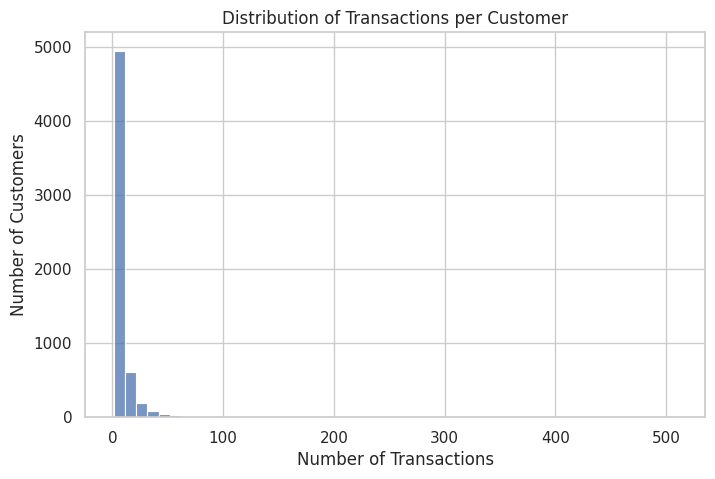

In [ ]:
# ======================================
# SECTION 2: MISSING VALUES, CUSTOMER COUNTS, AND BASIC EDA
# ======================================

# Check missing values by column and sort in descending order
na_summary = df.isna().sum().sort_values(ascending=False)
print("Missing values by column:")
print(na_summary)

# Show only columns that actually have missing values
print("\nColumns with missing values only:")
print(df.isna().sum().sort_values(ascending=False).loc[lambda s: s > 0].head(20))

# Count missing values again using isnull()
print("\nNull values by column:")
print(df.isnull().sum())

# Count number of unique customers
print("\nNumber of unique customers:", df['Customer ID'].nunique())

# Count unique invoices per customer
customer_transactions = df.groupby('Customer ID')['Invoice'].nunique()

# Summary statistics of customer transaction frequency
print("\nCustomer transaction summary:")
print(customer_transactions.describe())

# Plot histogram of number of transactions per customer
plt.figure(figsize=(8,5))
sns.histplot(customer_transactions, bins=50)
plt.title("Distribution of Transactions per Customer")
plt.xlabel("Number of Transactions")
plt.ylabel("Number of Customers")
plt.show()

This output shows **data quality checks** and **customer behavior patterns** from your transaction dataset:

**Missing Values Summary:**
- `Customer ID`: **243,007 missing** (22.8% of 1.07M rows) — common in retail data (guest checkouts, returns without customer ID, etc.)
- `Description`: **4,382 missing** (0.4%) — minor issue, product descriptions are mostly complete
- All other columns (`Invoice`, `StockCode`, `Quantity`, `Price`, `Country`) have **0 missing values**

**Unique Customers:**
- **5,942 unique customers** — this is the number of customers *with* a Customer ID (after excluding the 243K guest transactions)

**Customer Transaction Summary:**
- count 5942.000000 # 5,942 customers with ID
- mean 7.552339 # Average ~7.6 invoices per customer
- std 15.972262 # High standard deviation = skewed distribution
- min 1.000000 # Some customers only bought once
- 25% 2.000000 # 25% have 2 or fewer invoices
- 50% 4.000000 # Median = 4 invoices per customer
- 75% 8.000000 # 75% have 8 or fewer invoices
- max 510.000000 # ONE customer made 510 purchases!

**Histogram Interpretation:**
- **Tall bar at 0-1 transactions**: ~4,000 customers bought only **1-2 times** (most common)
- **Long tail to 500+**: A tiny fraction of customers are **extremely active** (whales)
- **Classic power-law distribution** typical of e-commerce: few customers drive most activity


**Key Findings**

- Most customers are **occasional buyers** (1-8 invoices), but a small group is **highly engaged**
- This **skewed distribution** is perfect for Pareto analysis (80/20 rule) and RFM segmentation


### Section 3: Return Transaction Analysis

This section isolates “return” transactions where `Quantity` is negative and computes several key metrics related to returns. It counts total transactions, purchase transactions, and return transactions, and calculates the return rate as a percentage of all transactions. It also sums the absolute number of units returned.

To help identify problem products, it groups returned items by product description and lists the top‑10 products with the highest return quantities. Finally, it visualizes the balance between purchases and returns using a simple bar chart.

This analysis helps quantify the size of returns, identify high‑return products, and visually compare buying versus returning behavior.

Output:
The output shows the return rate, total units returned, a list of top‑return products, and a bar chart comparing purchase versus return transactions.

In [ ]:
# ======================================
# SECTION 3: BASIC PRODUCT METRICS AND REVENUE CALCULATION
# ======================================

# Count unique product codes
print("Unique products (StockCode):", df['StockCode'].nunique())

# Count unique invoices
print("Unique invoices:", df['Invoice'].nunique())

# Create total revenue column for each line item
df['TotalPrice'] = df['Quantity'] * df['Price']

# Print total revenue before final cleaning
print("Total revenue before final cleaning:", df['TotalPrice'].sum())

# Remove rows with missing Customer ID
df = df.dropna(subset=['Customer ID'])

# Check remaining missing values
print("\nMissing values after dropping missing Customer ID:")
print(df.isnull().sum())

# Remove rows with missing product description
df = df.dropna(subset=['Description'])

# Print current dataset shape
print("\nDataset shape after removing missing Customer ID and Description:")
print(df.shape)

Unique products (StockCode): 5305
Unique invoices: 53628
Total revenue before final cleaning: 19287250.56799999

Missing values after dropping missing Customer ID:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

Dataset shape after removing missing Customer ID and Description:
(824364, 9)




**Key Business Metrics:**
- **Unique products (StockCode): 5,305**  
  The retailer sells **5,305 distinct products** (identified by StockCode).

- **Unique invoices: 53,628**  
  There are **53,628 separate orders/invoices** in the dataset.

- **Total revenue before final cleaning: £19,287,251**  
  **£19.3 million** in total sales across all transactions (before removing missing data).

**Data Cleaning Results:**
Missing values after dropping Customer ID rows: ALL COLUMNS = 0 missing
Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country, TotalPrice


**Final Clean Dataset:**
- **Shape: (824,364, 9)**  
  - **824,364 rows**: Down from 1.07M after dropping **243K rows** without Customer ID (~23%)  
  - **9 columns**: Original 8 + new `TotalPrice` column

**Changes:**
- Original dataset: 1,067,371 rows × 8 columns
- After cleaning: 824,364 rows × 9 columns
- Rows removed: 243,007 rows (23%) — all missing Customer ID
- Columns added: 1 column — TotalPrice = Quantity × Price


**Key Findings:**
- A **clean customer‑level dataset** with **£19.3M revenue** across **53K orders**
- **5,305 products** gives good variety for product‑level analysis (Pareto, top sellers)
- **No missing values** in any column — ready for RFM, time analysis, and product insights
- **Customer ID is now complete** (824K customer transactions) for RFM segmentation


### Section 4: Data Cleaning and Post‑Cleanup Validation

This section finalizes the cleaning of the dataset by removing rows with missing `Customer ID` and `Description`, and filtering out transactions with non‑positive `Quantity` (returns/cancellations) to keep only purchase records. It then checks for any remaining negative‑quantity transactions and cancelled invoices (those starting with "C").

It prints a structured validation summary that reports:
- dataset shape,
- remaining negative‑quantity transactions,
- cancelled invoices,
- missing values per column,
- sample revenue calculations,
- the data type of `InvoiceDate`,
- and key dataset statistics such as unique customers, unique products, total transactions, and total revenue.

This block serves as a “final sanity check” that the dataset is clean and ready for time‑based and product‑level analysis.

Output:
The output confirms that the dataset is cleaned, shows the remaining counts of negatives and cancellations, and provides a concise summary of key statistics and revenue.

========== DATASET RETURN ANALYSIS ==========

Total Transactions in Dataset: 824364
Total Purchase Transactions: 805620
Total Return Transactions: 18744

---------- RETURN METRICS ----------
Return Rate (% of all transactions): 2.27%
Total Units Returned: 486793

---------- TOP PRODUCTS WITH MOST RETURNS ----------
Description
PAPER CRAFT , LITTLE BIRDIE           -80995
MEDIUM CERAMIC TOP STORAGE JAR        -74494
ROTATING SILVER ANGELS T-LIGHT HLDR   -18730
SET/6 FRUIT SALAD PAPER CUPS           -7140
SET/6 FRUIT SALAD  PAPER PLATES        -7008
Manual                                 -5311
POP ART PEN CASE & PENS                -5184
BLACK SILVER FLOWER T-LIGHT HOLDER     -5040
MULTICOLOUR SPRING FLOWER MUG          -4996
TEATIME PEN CASE & PENS                -4632
Name: Quantity, dtype: int64


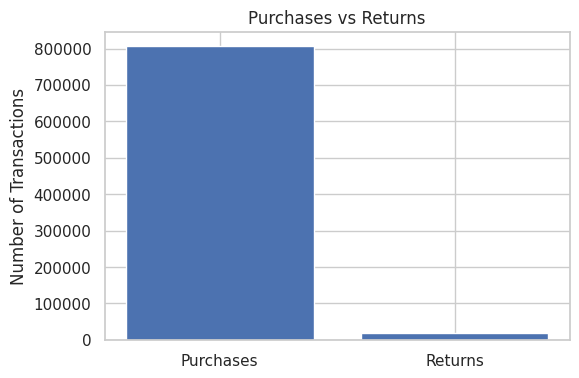

In [ ]:
# ======================================
# SECTION 4: RETURN ANALYSIS
# ======================================

# Identify return transactions where quantity is negative
returns = df[df['Quantity'] < 0]

# Count total, purchase, and return transactions
total_transactions = df.shape[0]
return_transactions = returns.shape[0]
purchase_transactions = df[df['Quantity'] > 0].shape[0]

# Calculate return rate
return_rate = (return_transactions / total_transactions) * 100

# Calculate total returned units
total_returned_units = abs(returns['Quantity'].sum())

# Print return analysis summary
print("========== DATASET RETURN ANALYSIS ==========\n")
print(f"Total Transactions in Dataset: {total_transactions}")
print(f"Total Purchase Transactions: {purchase_transactions}")
print(f"Total Return Transactions: {return_transactions}")

print("\n---------- RETURN METRICS ----------")
print(f"Return Rate (% of all transactions): {return_rate:.2f}%")
print(f"Total Units Returned: {total_returned_units}")

print("\n---------- TOP PRODUCTS WITH MOST RETURNS ----------")
top_returns = returns.groupby('Description')['Quantity'].sum().sort_values().head(10)
print(top_returns)

# Visualize purchases vs returns
plt.figure(figsize=(6,4))
plt.bar(['Purchases', 'Returns'], [purchase_transactions, return_transactions])
plt.title("Purchases vs Returns")
plt.ylabel("Number of Transactions")
plt.show()

### Explanation of Section 4 Output (Return Analysis)

**Transaction Breakdown:**
-Total Transactions: 824,364 rows
- Purchase Transactions: 805,620 rows (97.73%)
- Return Transactions: 18,744 rows (2.27%)


**Return Metrics:**
- **Return Rate: 2.27%** — For every 100 transactions, ~2 are returns. This is **low and healthy**.
- **Total Units Returned: 486,793** — Customers returned **nearly 487K units** across all return transactions.

**Top Products with Most Returns:**
PAPER CRAFT, LITTLE BIRDIE: -80,995 units returned            
MEDIUM CERAMIC TOP STORAGE JAR: -74,494 units returned                         
ROTATING SILVER ANGELS: -18,730 units returned

These are **high‑volume decorative items** (paper crafts, ceramic jars, holiday decor) that customers bought in bulk but returned in large quantities.

**Bar Chart Interpretation:**
- **Purchases bar**: ~806K
- **Returns bar**: ~19K
- **Visual takeaway**: Returns are a **tiny fraction** of purchase activity.


**Key Findings**
- **Low return rate** (2.27%) indicates good product quality and customer satisfaction
- **Decorative items have high return volume** — consider **lower stock levels** or **promotional pricing** for these SKUs
- **Returns are manageable** and won't significantly impact your revenue or RFM calculations
- The dataset is **healthy** for inventory planning: most activity is purchases, not returns

### Section 5: Product‑Level Pareto Analysis (80–20 Rule)

This section performs a Pareto (80–20) analysis at the product level. It groups total sales by product description, sums revenue per product, and sorts products in descending order of revenue. A cumulative‑revenue percentage curve is plotted to see how quickly the top products account for 80% of total revenue.

It then calculates how many products lie within the 80% cumulative revenue threshold and reports this as a percentage of total products. This helps identify whether a small subset of products drives most of the sales, which is useful for inventory prioritization and focusing on the “vital few” SKUs.

Output:
The output includes a Pareto curve visual and numeric results showing how many products contribute to 80% of total revenue.

In [ ]:
# ======================================
# SECTION 5: DATA CLEANING AND POST-CLEANING VALIDATION
# ======================================

# Drop any remaining missing customer IDs and descriptions
df = df.dropna(subset=['Customer ID'])
df = df.dropna(subset=['Description'])

# Keep only positive quantity transactions (remove returns from main sales analysis)
df = df[df['Quantity'] > 0]

# Check if any negative quantity rows remain
negative_qty = df[df['Quantity'] < 0]
print("Negative quantity transactions:", negative_qty.shape[0])

# Print validation summary
print("\n========== DATASET VALIDATION SUMMARY ==========\n")

# 1. Dataset shape
print("1. Dataset Shape (rows, columns):")
print(df.shape)

# 2. Check negative quantities
print("\n2. Negative Quantity Transactions:")
print("Count:", negative_qty.shape[0])

# 3. Check cancelled invoices
cancelled_invoices = df[df['Invoice'].astype(str).str.startswith('C')]
print("\n3. Cancelled Invoice Transactions:")
print("Count:", cancelled_invoices.shape[0])

# 4. Check missing values
print("\n4. Missing Values by Column:")
print(df.isnull().sum())

# 5. Recalculate revenue column
df['TotalPrice'] = df['Quantity'] * df['Price']
print("\n5. Sample Revenue Calculation:")
print(df[['Quantity', 'Price', 'TotalPrice']].head())

# 6. Check date type
print("\n6. InvoiceDate Data Type:")
print(df['InvoiceDate'].dtype)

# 7. Key dataset statistics
print("\n7. Key Dataset Statistics:")
print("Unique Customers:", df['Customer ID'].nunique())
print("Unique Products:", df['StockCode'].nunique())
print("Total Transactions:", df['Invoice'].nunique())
print("Total Revenue:", round(df['TotalPrice'].sum(), 2))

print("\n========== VALIDATION COMPLETE ==========")

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

Negative quantity transactions: 0

========== DATASET VALIDATION SUMMARY ==========

1. Dataset Shape (rows, columns):
(805620, 9)

2. Negative Quantity Transactions:
Count: 0

3. Cancelled Invoice Transactions:
Count: 0

4. Missing Values by Column:
Invoice        0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
Price          0
Customer ID    0
Country        0
TotalPrice     0
dtype: int64

5. Sample Revenue Calculation:
   Quantity  Price  TotalPrice
0        12   6.95        83.4
1        12   6.75        81.0
2        12   6.75        81.0
3        48   2.10       100.8
4        24   1.25        30.0

6. InvoiceDate Data Type:
object

7. Key Dataset Statistics:
Unique Customers: 5881
Unique Products: 4631
Total Transactions: 36975
Total Revenue: 17743429.18

========== VALIDATION COMPLETE ==========



**Summary of the output:**

- **Negative quantity transactions:** `0`  
  All return lines have been removed from this cleaned dataset.

- **Dataset shape:** `(805620, 9)`  
  The final purchase dataset contains **805,620 rows** and **9 columns** (including the `TotalPrice` column).

- **Cancelled invoices:** `0`  
  There are no remaining cancelled invoices after filtering.

- **Missing values:**  
  All columns (`Invoice`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `Price`, `Customer ID`, `Country`, `TotalPrice`) have **0 missing values**, so the dataset is fully complete.

- **Revenue check (sample rows):**  
  The sample output confirms that `TotalPrice` is correctly computed as `Quantity × Price`, for example:
  - `12 × 6.95 = 83.40`
  - `48 × 2.10 = 100.80`

- **InvoiceDate type:** `object`  
  This is then converted to `datetime` at the end of the section for use in time‑series and seasonality analysis.

- **Key business statistics after cleaning:**
  - **Unique Customers:** `5,881`
  - **Unique Products:** `4,631`
  - **Total Transactions (invoices):** `36,975`
  - **Total Revenue:** `17,743,429.18` (approximately **£17.7M**)

Overall, Section 5 ensures that the dataset is **fully clean, contains only valid purchase transactions, and has no missing values**, making it suitable for the subsequent analyses such as Pareto, RFM segmentation, and inventory planning.

### Section 6: Customer‑Level Pareto Analysis

This section performs Pareto analysis at the customer level. It computes the total revenue generated by each customer, sorts customers from highest to lowest revenue, and calculates the cumulative percentage of revenue they contribute. A curve is plotted to show how many customers are needed to reach 80% of total revenue.

This analysis helps identify whether a small group of high‑value customers accounts for the majority of revenue. It is useful for understanding customer concentration, focusing acquisition and retention efforts, and later linking high‑value segments to inventory decisions.

Output:
The output shows a customer‑revenue cumulative curve and numeric results indicating how many customers generate 80% of total revenue.

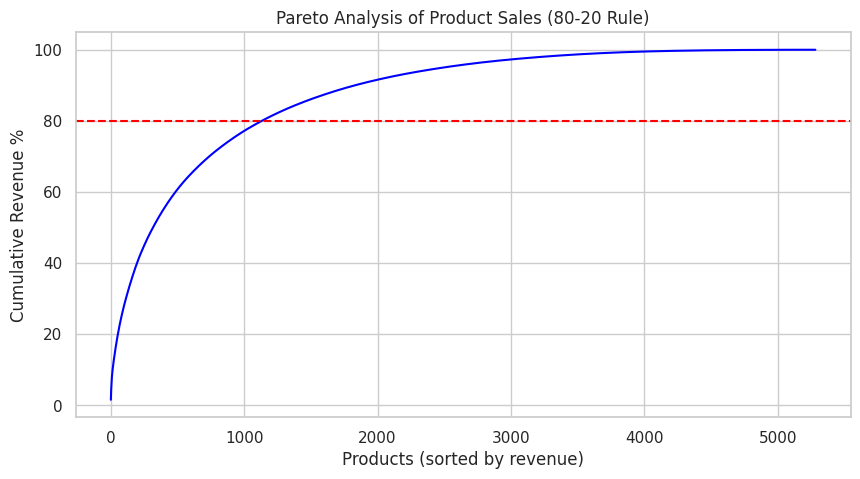


========== PRODUCT PARETO RESULT ==========

Total Products: 5283
Products contributing to 80% revenue: 1131
Percentage of products generating 80% revenue: 21.41 %


In [ ]:
# ======================================
# SECTION 6: PRODUCT-LEVEL PARETO ANALYSIS
# ======================================

# Calculate total sales per product
product_sales = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)

# Convert to DataFrame
pareto_df = product_sales.reset_index()
pareto_df.columns = ['Product', 'Sales']

# Compute cumulative sales and cumulative percentage
pareto_df['Cumulative_Sales'] = pareto_df['Sales'].cumsum()
pareto_df['Cumulative_Percentage'] = 100 * pareto_df['Cumulative_Sales'] / pareto_df['Sales'].sum()

# Plot Pareto chart
plt.figure(figsize=(10,5))
plt.plot(pareto_df['Cumulative_Percentage'], color='blue')
plt.axhline(80, color='red', linestyle='--')
plt.title("Pareto Analysis of Product Sales (80-20 Rule)")
plt.xlabel("Products (sorted by revenue)")
plt.ylabel("Cumulative Revenue %")
plt.show()

# Count products contributing to 80% of revenue
products_80 = pareto_df[pareto_df['Cumulative_Percentage'] <= 80]

print("\n========== PRODUCT PARETO RESULT ==========\n")
print("Total Products:", pareto_df.shape[0])
print("Products contributing to 80% revenue:", products_80.shape[0])
print("Percentage of products generating 80% revenue:",
      round(products_80.shape[0] / pareto_df.shape[0] * 100, 2), "%")


This section analyses how product sales are concentrated using the Pareto principle (80–20 rule).

**Chart interpretation (blue curve + red dashed line):**
- The **x‑axis** shows products sorted from **highest to lowest revenue**.
- The **y‑axis** shows **cumulative revenue percentage**.
- The **blue curve** starts near 0% and gradually approaches 100% as we add more products.
- The **red dashed horizontal line at 80%** marks the **80% revenue level**.  
  The point where the blue curve crosses this line tells us **how many products generate 80% of total revenue**.

**What this means:**
- Only about **21% of products (1,131 out of 5,283)** are responsible for **80% of total revenue**.
- The remaining ~79% of products together contribute only 20% of revenue.
- This is a **strong Pareto effect**, which is typical in retail: a relatively small set of “hero” products drives most of the business.

### Section 7: Monthly Sales Trends and Seasonality Analysis

This section creates year‑ and month‑level features from `InvoiceDate` and aggregates revenue by month‑year to study the overall sales trend over time. It prints the monthly revenue series and plots it as a line chart, showing whether sales are increasing, decreasing, or stabilizing.

Separately, it groups revenue by calendar month (ignoring year) to study seasonality, and visualizes the pattern using a bar chart. This helps identify recurring peaks or troughs in demand by month, which is important for planning promotions, stock levels, and supply chain activities.

Output:
The output includes a monthly revenue trend plot and a bar chart showing the seasonal revenue pattern by month.

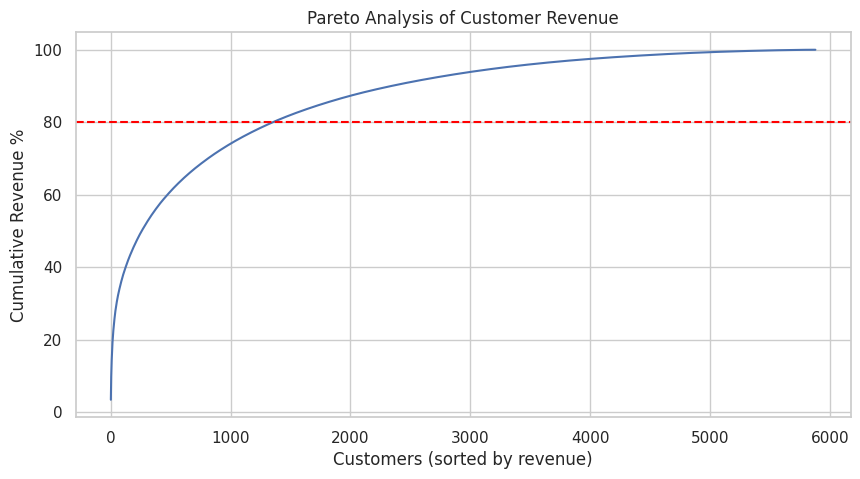


========== CUSTOMER PARETO RESULT ==========

Total Customers: 5881
Customers generating 80% revenue: 1352
Percentage of customers generating 80% revenue: 22.99 %

========== MONTHLY SALES SUMMARY ==========

YearMonth
2009-12     686654.160
2010-01     557319.062
2010-02     506371.066
2010-03     699608.991
2010-04     594609.192
2010-05     599985.790
2010-06     639066.580
2010-07     591636.740
2010-08     604242.650
2010-09     831615.001
2010-10    1036680.000
2010-11    1172336.042
2010-12     884591.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518210.790
Freq: M, Name: TotalPrice, dtype: float64


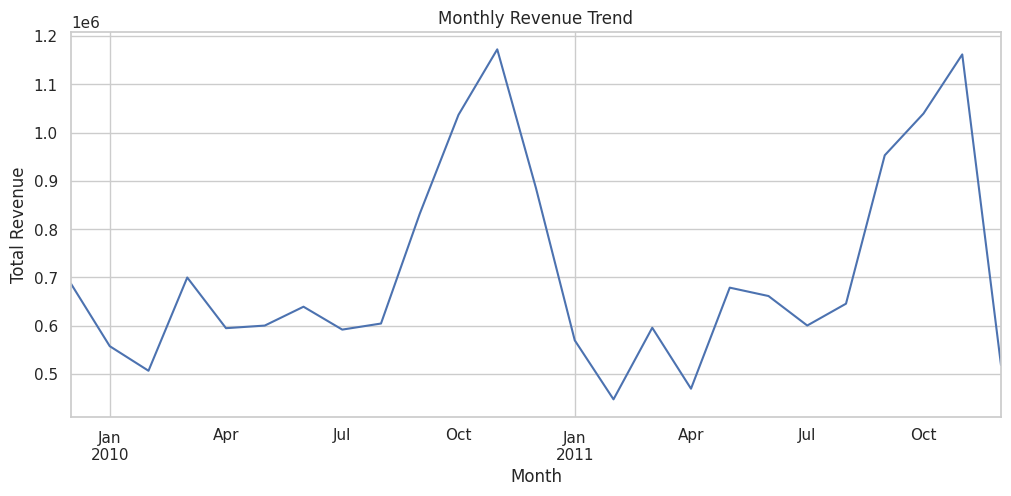

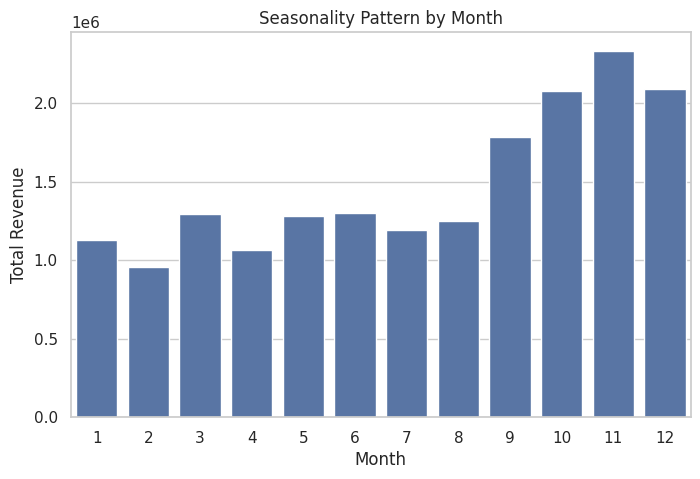

In [ ]:
# ======================================
# SECTION 7: CUSTOMER PARETO + MONTHLY SALES + SEASONALITY
# ======================================

# ----- Customer Pareto Analysis -----

# Total revenue per customer
customer_sales = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False)

# Convert to DataFrame
customer_df = customer_sales.reset_index()
customer_df.columns = ['CustomerID', 'Revenue']

# Compute cumulative revenue percentage
customer_df['Cumulative_Revenue'] = customer_df['Revenue'].cumsum()
customer_df['Cumulative_Percentage'] = 100 * customer_df['Cumulative_Revenue'] / customer_df['Revenue'].sum()

# Plot customer Pareto curve
plt.figure(figsize=(10,5))
plt.plot(customer_df['Cumulative_Percentage'])
plt.axhline(80, color='red', linestyle='--')
plt.title("Pareto Analysis of Customer Revenue")
plt.xlabel("Customers (sorted by revenue)")
plt.ylabel("Cumulative Revenue %")
plt.show()

# Customers contributing to 80% of revenue
customers_80 = customer_df[customer_df['Cumulative_Percentage'] <= 80]

print("\n========== CUSTOMER PARETO RESULT ==========\n")
print("Total Customers:", customer_df.shape[0])
print("Customers generating 80% revenue:", customers_80.shape[0])
print("Percentage of customers generating 80% revenue:",
      round(customers_80.shape[0] / customer_df.shape[0] * 100, 2), "%")

# ----- Monthly Sales Trend -----

# Create year, month, and year-month columns
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# Aggregate monthly sales
monthly_sales = df.groupby('YearMonth')['TotalPrice'].sum()

print("\n========== MONTHLY SALES SUMMARY ==========\n")
print(monthly_sales)

# Plot monthly sales trend
plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.grid(True)
plt.show()

# ----- Monthly Seasonality -----

monthly_pattern = df.groupby(df['InvoiceDate'].dt.month)['TotalPrice'].sum()

plt.figure(figsize=(8,5))
sns.barplot(x=monthly_pattern.index, y=monthly_pattern.values)
plt.title("Seasonality Pattern by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

From the customer‑level Pareto analysis:

- **Total customers with ID:** `5,881`
- **Customers generating 80% of revenue:** `1,352`
- **Share of customers generating 80% of revenue:** `22.99%`

This means that **only about 23% of customers account for 80% of total revenue**. The corresponding Pareto curve is steep at the beginning and then flattens out, which is a typical pattern in retail: a relatively small set of **high‑value customers** drives most of the business, while the majority of customers contribute a smaller share of revenue. These top 1,352 customers are key targets for retention, loyalty programs, and personalized campaigns.

---

#### Monthly Revenue Trend (Time-Series View)

The monthly revenue series (Dec 2009 – Dec 2011) shows how total sales evolved over time:

- Revenue fluctuates between roughly **£450K and £700K** for most months.
- There are clear **spikes in September–November** of each year:
  - **2010‑09 to 2010‑11**: revenue rises from ~£0.83M to ~£1.17M.
  - **2011‑09 to 2011‑11**: revenue again climbs to just above **£1.16M**.
- After November 2011, revenue drops sharply in **December 2011** to about **£0.52M**.


---

#### Seasonality Pattern by Month (Across Both Years)

When aggregating revenue by calendar month (1–12) across the entire period:

- **Highest‑revenue months:**  
  - **October, November, and December** clearly stand out with the **highest bars**, indicating strong demand in Q4.
- **Mid‑range months:**  
  - Months like **March, May, June, and August** sit in the middle, with steady but not peak revenue.
- **Lower‑revenue months:**  
  - Early months such as **January and February** tend to have **lower total revenue** compared to the year‑end period.

The bar chart (“Seasonality Pattern by Month”) confirms a clear **seasonal pattern**, with sales **building up toward the end of the year**. This is consistent with typical retail behavior driven by holiday and gift‑buying seasons.

---

### Section 8: Product‑Level Top‑Performers and Demand Consistency

This section identifies the top‑20 products by revenue and by total quantity sold, then visualizes both using horizontal bar charts. This helps distinguish products that generate the most money from products that sell the highest number of units, which can inform different inventory and marketing strategies.

It also studies demand consistency by computing, for each product, the total units sold and the number of distinct months in which the product appears in the sales records. The results are combined into a single DataFrame sorted by demand, highlighting products that are both high‑volume and consistently sold over time.

This analysis is useful for identifying reliable, steady‑selling products versus sporadic or “one‑off” sellers for inventory planning.

Output:
The output lists the top‑20 products by revenue and quantity sold, and shows a table of products with total units sold and months with sales.


========== TOP 20 PRODUCTS BY REVENUE ==========

Description
REGENCY CAKESTAND 3 TIER               286486.30
WHITE HANGING HEART T-LIGHT HOLDER     252072.46
PAPER CRAFT , LITTLE BIRDIE            168469.60
Manual                                 152340.57
JUMBO BAG RED RETROSPOT                136980.08
ASSORTED COLOUR BIRD ORNAMENT          127074.17
POSTAGE                                126563.04
PARTY BUNTING                          103880.23
MEDIUM CERAMIC TOP STORAGE JAR          81416.73
PAPER CHAIN KIT 50'S CHRISTMAS          79594.33
CHILLI LIGHTS                           72860.14
BLACK RECORD COVER FRAME                67209.44
JUMBO BAG STRAWBERRY                    64601.65
WOOD BLACK BOARD ANT WHITE FINISH       60513.09
ROTATING SILVER ANGELS T-LIGHT HLDR     57779.17
VINTAGE UNION JACK BUNTING              54815.12
EDWARDIAN PARASOL NATURAL               54741.46
JUMBO  BAG BAROQUE BLACK WHITE          53168.34
CREAM HEART CARD HOLDER                 52627.29
HEART 

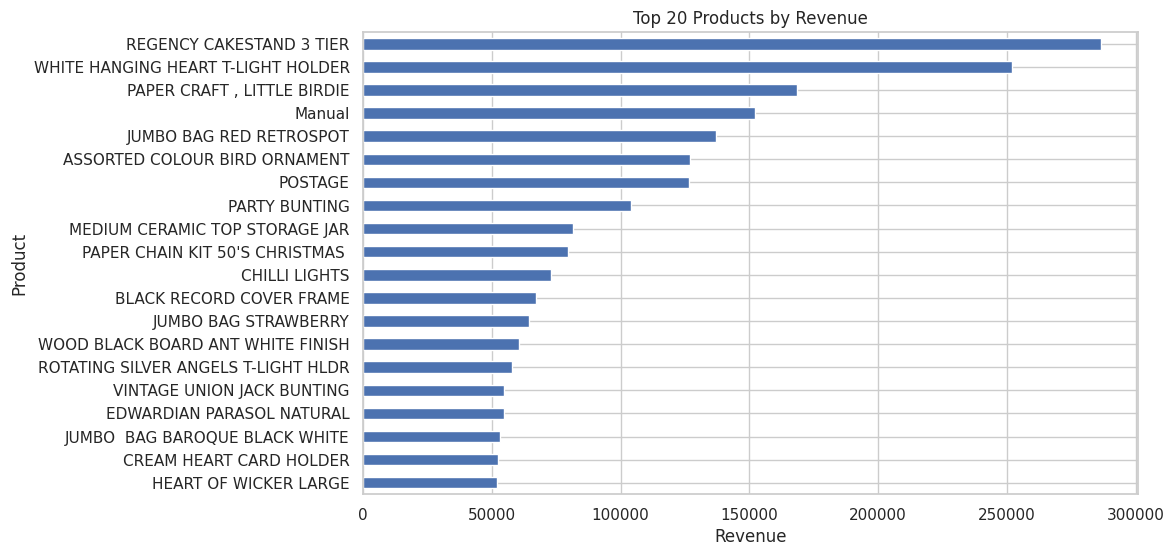


========== TOP 20 PRODUCTS BY QUANTITY SOLD ==========

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS      109169
WHITE HANGING HEART T-LIGHT HOLDER      93640
PAPER CRAFT , LITTLE BIRDIE             80995
ASSORTED COLOUR BIRD ORNAMENT           79913
MEDIUM CERAMIC TOP STORAGE JAR          77916
JUMBO BAG RED RETROSPOT                 75759
BROCADE RING PURSE                      71129
PACK OF 60 PINK PAISLEY CAKE CASES      55270
60 TEATIME FAIRY CAKE CASES             53495
PACK OF 72 RETROSPOT CAKE CASES         46107
PACK OF 72 RETRO SPOT CAKE CASES        45156
SMALL POPCORN HOLDER                    43970
MINI PAINT SET VINTAGE                  43621
ASSORTED COLOURS SILK FAN               41078
COLOUR GLASS T-LIGHT HOLDER HANGING     39643
PACK OF 72 SKULL CAKE CASES             38927
PACK OF 12 LONDON TISSUES               38084
VICTORIAN GLASS HANGING T-LIGHT         37851
RED  HARMONICA IN BOX                   37097
JUMBO BAG STRAWBERRY                    36098
Name: Quant

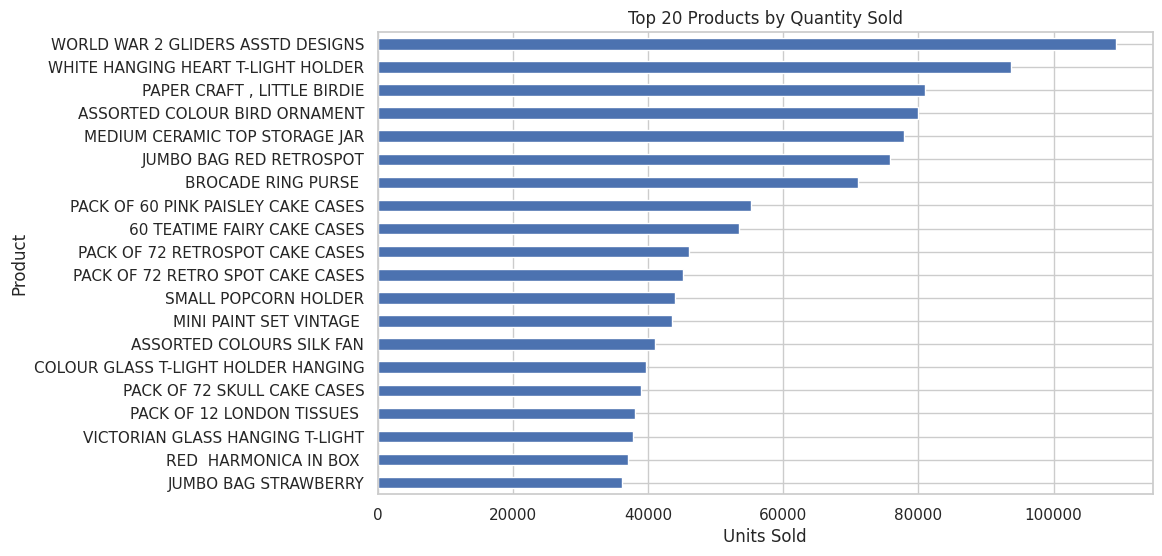


========== PRODUCT DEMAND CONSISTENCY ==========

                                     Total_Units_Sold  Months_With_Sales
Description                                                             
WORLD WAR 2 GLIDERS ASSTD DESIGNS              109169                 25
WHITE HANGING HEART T-LIGHT HOLDER              93640                 25
PAPER CRAFT , LITTLE BIRDIE                     80995                  1
ASSORTED COLOUR BIRD ORNAMENT                   79913                 25
MEDIUM CERAMIC TOP STORAGE JAR                  77916                  9
JUMBO BAG RED RETROSPOT                         75759                 20
BROCADE RING PURSE                              71129                 25
PACK OF 60 PINK PAISLEY CAKE CASES              55270                 25
60 TEATIME FAIRY CAKE CASES                     53495                 25
PACK OF 72 RETROSPOT CAKE CASES                 46107                 16
PACK OF 72 RETRO SPOT CAKE CASES                45156                 12


In [ ]:
# ======================================
# SECTION 8: TOP PRODUCTS AND DEMAND CONSISTENCY
# ======================================

# Top 20 products by revenue
top_revenue_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(20)

print("\n========== TOP 20 PRODUCTS BY REVENUE ==========\n")
print(top_revenue_products)

plt.figure(figsize=(10,6))
top_revenue_products.sort_values().plot(kind='barh')
plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")
plt.show()

# Top 20 products by quantity sold
top_demand_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20)

print("\n========== TOP 20 PRODUCTS BY QUANTITY SOLD ==========\n")
print(top_demand_products)

plt.figure(figsize=(10,6))
top_demand_products.sort_values().plot(kind='barh')
plt.title("Top 20 Products by Quantity Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product")
plt.show()

# Product demand consistency analysis
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

product_demand = df.groupby('Description')['Quantity'].sum()
product_months = df.groupby('Description')['YearMonth'].nunique()

product_analysis = pd.DataFrame({
    'Total_Units_Sold': product_demand,
    'Months_With_Sales': product_months
})

product_analysis = product_analysis.sort_values(by='Total_Units_Sold', ascending=False)

print("\n========== PRODUCT DEMAND CONSISTENCY ==========\n")
print(product_analysis.head(20))

#### 1. Product Demand Consistency

The `PRODUCT DEMAND CONSISTENCY` table combines:
- **Total_Units_Sold** – total quantity sold for each product.
- **Months_With_Sales** – number of distinct months in which that product had at least one sale.

Key observations:
- **WORLD WAR 2 GLIDERS ASSTD DESIGNS**
  - **109,169 units sold** across **25 months**.
  - This product is both **high‑volume** and **very consistent** (present almost every month).
- **WHITE HANGING HEART T‑LIGHT HOLDER**
  - **93,640 units**, also sold in **25 months**.
  - Extremely steady demand, making it a strong candidate for priority stocking.
- **ASSORTED COLOUR BIRD ORNAMENT**, **BROCADE RING PURSE**, **ASSORTED COLOURS SILK FAN**, **VICTORIAN GLASS HANGING T‑LIGHT**, **JUMBO BAG STRAWBERRY**, etc.
  - All show **40K+ units sold** and visibility in **20–25 months**, indicating **stable, long‑term demand**.
- **PAPER CRAFT, LITTLE BIRDIE**
  - **80,995 units sold** but only in **1 month**.
  - This looks like a **one‑time bulk or seasonal spike** rather than a steady product.

Overall, most top products show **high units sold across many months**, meaning they are **reliable sellers**, while a few items are **highly seasonal or campaign‑driven**.

---

#### 2. Top 20 Products by Quantity Sold

From `TOP 20 PRODUCTS BY QUANTITY SOLD` and the bar chart:

- The **highest‑volume product** is **WORLD WAR 2 GLIDERS ASSTD DESIGNS** with **109,169 units** sold.
- Other major volume drivers include:
  - **WHITE HANGING HEART T‑LIGHT HOLDER** – 93,640 units  
  - **PAPER CRAFT, LITTLE BIRDIE** – 80,995 units  
  - **ASSORTED COLOUR BIRD ORNAMENT** – 79,913 units  
  - **MEDIUM CERAMIC TOP STORAGE JAR** – 77,916 units  
  - **JUMBO BAG RED RETROSPOT** – 75,759 units  
- Many of the remaining top‑20 products are **gift, home‑decor, or party items** (cake cases, bags, purses, t‑light holders).

These products dominate the **unit volume** and therefore heavily influence **warehouse movements and picking activity**.

---

#### 3. Top 20 Products by Revenue

From `TOP 20 PRODUCTS BY REVENUE` and its bar chart:

- **REGENCY CAKESTAND 3 TIER** is the **top revenue generator** with **£286,486.30**, even if it doesn't appear in the top‑quantity list, indicating a **high price or higher margin**.
- **WHITE HANGING HEART T‑LIGHT HOLDER** and **PAPER CRAFT, LITTLE BIRDIE** are strong in **both quantity and revenue**, making them **strategic products**:
  - White Heart T‑Light Holder – **£252,072.46**
  - Paper Craft, Little Birdie – **£168,469.60**
- Other notable high‑revenue items include:
  - **JUMBO BAG RED RETROSPOT** – £136,980.08  
  - **ASSORTED COLOUR BIRD ORNAMENT** – £127,074.17  
  - **POSTAGE** and **PARTY BUNTING** – revenue above £100K  
  - Several decorative/home products (e.g., **CHILLI LIGHTS**, **BLACK RECORD COVER FRAME**, **JUMBO BAG STRAWBERRY**, **ROTATING SILVER ANGELS T‑LIGHT HLDR**).

Revenue ranking shows which products **financially matter most**, not just which sell the most units.

---

#### 4. Insights for Inventory and Planning

- Products that are **top in both units and revenue** and have **many Months_With_Sales** (e.g., **White Hanging Heart T‑Light Holder**, **Assorted Colour Bird Ornament**, **Jumbo Bag Red Retrospot**, **Jumbo Bag Strawberry**) should be treated as **core catalogue items** with:
  - high service level targets,
  - strong safety stock,
  - and priority in replenishment and forecasting models.
- Products with **very high volume but low Months_With_Sales** (e.g., **Paper Craft, Little Birdie**) are likely **seasonal or campaign‑based** and require:
  - careful **pre‑season stocking**,
  - and **post‑season clearance planning** to avoid over‑stocking.
- High‑revenue but not necessarily high‑volume items (e.g., **Regency Cakestand 3 Tier**) can be **margin drivers** and may justify:
  - more expensive storage or handling,
  - and targeted marketing, even at lower unit volumes.

Overall, this section identifies **which products drive demand and revenue**, and shows that a combination of **steady high‑volume products** and **high‑value items** should be central to inventory decisions.

### Section 9: RFM Creation, Validation, Scoring, Segmentation, and Segment‑Level Revenue

This section builds the RFM dataset at the customer level. It converts `InvoiceDate` to a proper datetime, defines a snapshot date just after the last transaction, and computes:
- Recency (days since the customer’s last purchase),
- Frequency (number of unique invoices),
- Monetary (total revenue).

The RFM table is validated for duplicates, invalid values, and basic statistics, and its distributions are visualized using boxplots.

Next, it scores Recency, Frequency, and Monetary into 1–5 tiers using quantiles, combines them into an `RFM_Score`, and applies a rule‑based segmentation function to label each customer into categories such as Champions, Loyal Customers, New Customers, At Risk, Lost, and Potential Loyalist. The segment distribution is summarized and visualized.

Finally, it aggregates revenue and other metrics at the segment level: counting customers, computing average and total revenue per segment, and visualizing revenue contribution by segment using a bar chart. This links customer behavior to business value and supports the inventory‑planning goal by identifying which segments drive the most revenue.

Output:
The output includes the RFM table, segment counts, a segment‑distribution plot, and a segment‑level revenue summary and chart.


,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


Total rows: 5881
Unique customers: 5881

RFM DATASET VALIDATION CHECKS

1️⃣ Checking CustomerID uniqueness
PASS: Each customer has exactly one row
Total rows: 5881
Unique customers: 5881

2️⃣ Duplicate Customer Check
Number of duplicated CustomerIDs: 0

3️⃣ Checking for invalid RFM values
Negative Recency values : 0
Zero/Negative Frequency : 0
Zero/Negative Monetary  : 3

4️⃣ RFM Summary Statistics


,Customer ID,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000,5881.000000
mean,15314.674205,201.457745,6.287196,3017.076888
std,1715.429759,209.474135,13.012879,14734.128619
min,12346.000000,1.000000,1.000000,0.000000
25%,13833.000000,26.000000,1.000000,347.800000
50%,15313.000000,96.000000,3.000000,897.620000
75%,16797.000000,380.000000,7.000000,2304.180000
max,18287.000000,739.000000,398.000000,608821.650000



5️⃣ Recency validation
Minimum Recency: 1
Maximum Recency: 739

6️⃣ Top 10 High Value Customers


,Customer ID,Recency,Frequency,Monetary
5695,18102.0,1,145,608821.65
2279,14646.0,2,152,528602.52
1791,14156.0,10,156,313946.37
2541,14911.0,1,398,295972.63
5053,17450.0,8,51,246973.09
1332,13694.0,4,143,196482.81
5112,17511.0,3,60,175603.55
4064,16446.0,1,2,168472.50
4298,16684.0,4,55,147142.77
68,12415.0,24,28,144458.37



7️⃣ Distribution plots


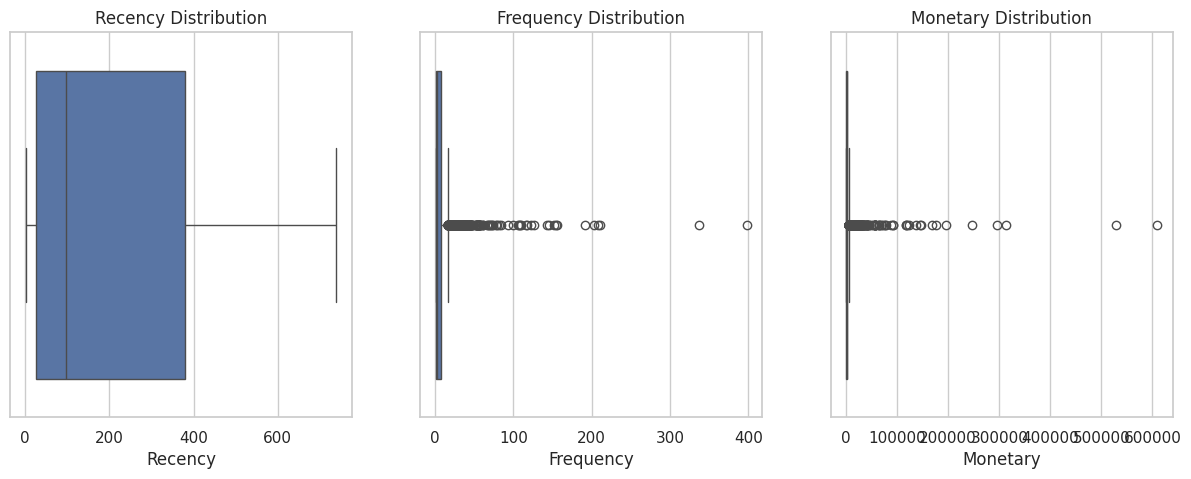


RFM DATASET VALIDATION COMPLETE

RFM SCORING

Sample RFM scores:


,Customer ID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255
1,12347.0,2,8,5633.32,5,4,5,545
2,12348.0,75,5,2019.40,3,4,4,344
3,12349.0,19,4,4428.69,5,3,5,535
4,12350.0,310,1,334.40,2,1,2,212



CUSTOMER SEGMENT DISTRIBUTION


,count
Segment,
Lost,1523
Champions,1482
Potential Loyalist,1090
Loyal Customers,869
At Risk,471
New Customers,443


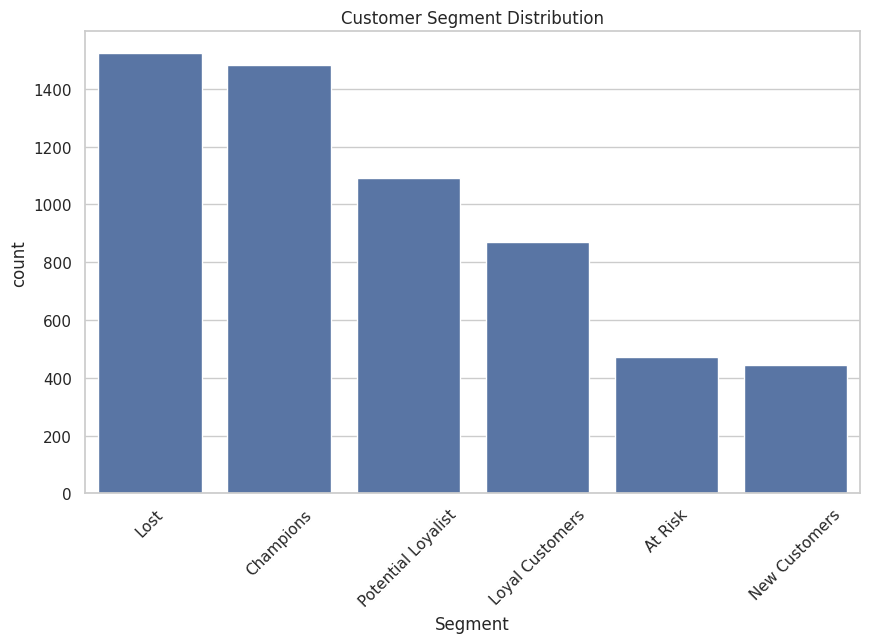


RFM SEGMENTATION COMPLETE

SEGMENT LEVEL BUSINESS SUMMARY


,Customer_Count,Avg_Monetary,Total_Revenue,Avg_Frequency,Avg_Recency
Segment,,,,,
Champions,1482,8294.965354,1.229314e+07,15.659244,20.367072
Loyal Customers,869,3276.505428,2.847283e+06,8.144994,202.940161
Potential Loyalist,1090,948.167141,1.033502e+06,2.508257,75.524771
Lost,1523,438.031466,6.671219e+05,1.252791,459.281024
At Risk,471,1078.013992,5.077446e+05,2.968153,387.753715
New Customers,443,890.832077,3.946386e+05,1.460497,28.106095



SEGMENT REVENUE SHARE


,Customer_Count,Avg_Monetary,Total_Revenue,Avg_Frequency,Avg_Recency,Revenue_%
Segment,,,,,,
Champions,1482,8294.965354,1.229314e+07,15.659244,20.367072,69.28
Loyal Customers,869,3276.505428,2.847283e+06,8.144994,202.940161,16.05
Potential Loyalist,1090,948.167141,1.033502e+06,2.508257,75.524771,5.82
Lost,1523,438.031466,6.671219e+05,1.252791,459.281024,3.76
At Risk,471,1078.013992,5.077446e+05,2.968153,387.753715,2.86
New Customers,443,890.832077,3.946386e+05,1.460497,28.106095,2.22



SEGMENT REVENUE VISUALIZATION


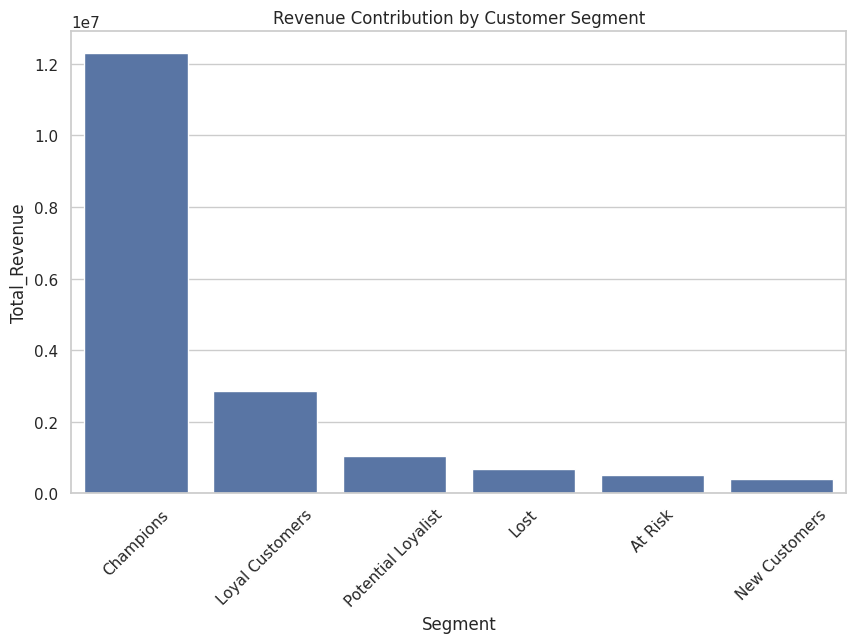

In [ ]:
# ======================================
# SECTION 9: RFM CREATION, VALIDATION, SEGMENTATION, AND SEGMENT REVENUE
# ======================================

# Ensure InvoiceDate is datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Define snapshot date
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby("Customer ID").agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Preview RFM
display(rfm.head())
print("Total rows:", len(rfm))
print("Unique customers:", rfm["Customer ID"].nunique())

# ----- RFM Validation -----
print("\n" + "="*70)
print("RFM DATASET VALIDATION CHECKS")
print("="*70)

print("\n1️⃣ Checking CustomerID uniqueness")
if rfm["Customer ID"].is_unique:
    print("PASS: Each customer has exactly one row")
else:
    print("FAIL: Duplicate customers found")

print("Total rows:", len(rfm))
print("Unique customers:", rfm["Customer ID"].nunique())

duplicates = rfm["Customer ID"].duplicated().sum()
print("\n2️⃣ Duplicate Customer Check")
print("Number of duplicated CustomerIDs:", duplicates)

if duplicates > 0:
    print("Duplicate rows:")
    display(rfm[rfm["Customer ID"].duplicated()])

print("\n3️⃣ Checking for invalid RFM values")
recency_negative = (rfm["Recency"] < 0).sum()
frequency_invalid = (rfm["Frequency"] <= 0).sum()
monetary_invalid = (rfm["Monetary"] <= 0).sum()

print("Negative Recency values :", recency_negative)
print("Zero/Negative Frequency :", frequency_invalid)
print("Zero/Negative Monetary  :", monetary_invalid)

print("\n4️⃣ RFM Summary Statistics")
display(rfm.describe())

print("\n5️⃣ Recency validation")
print("Minimum Recency:", rfm["Recency"].min())
print("Maximum Recency:", rfm["Recency"].max())

print("\n6️⃣ Top 10 High Value Customers")
display(rfm.sort_values("Monetary", ascending=False).head(10))

print("\n7️⃣ Distribution plots")
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.boxplot(x=rfm["Recency"])
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.boxplot(x=rfm["Frequency"])
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.boxplot(x=rfm["Monetary"])
plt.title("Monetary Distribution")

plt.show()

print("\n" + "="*70)
print("RFM DATASET VALIDATION COMPLETE")
print("="*70)

# ----- RFM Scoring -----
print("\n" + "="*70)
print("RFM SCORING")
print("="*70)

rfm = rfm[rfm["Monetary"] > 0]

rfm["R_score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 5, labels=[1,2,3,4,5])

rfm["R_score"] = rfm["R_score"].astype(int)
rfm["F_score"] = rfm["F_score"].astype(int)
rfm["M_score"] = rfm["M_score"].astype(int)

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

print("\nSample RFM scores:")
display(rfm.head())

# ----- Customer Segmentation -----
def segment_customer(row):
    if row["R_score"] >= 4 and row["F_score"] >= 4:
        return "Champions"
    elif row["F_score"] >= 4:
        return "Loyal Customers"
    elif row["R_score"] >= 4 and row["F_score"] <= 2:
        return "New Customers"
    elif row["R_score"] <= 2 and row["F_score"] >= 3:
        return "At Risk"
    elif row["R_score"] <= 2 and row["F_score"] <= 2:
        return "Lost"
    else:
        return "Potential Loyalist"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

print("\n" + "="*70)
print("CUSTOMER SEGMENT DISTRIBUTION")
print("="*70)

segment_counts = rfm["Segment"].value_counts()
display(segment_counts)

plt.figure(figsize=(10,6))
sns.countplot(data=rfm, x="Segment", order=segment_counts.index)
plt.xticks(rotation=45)
plt.title("Customer Segment Distribution")
plt.show()

print("\n" + "="*70)
print("RFM SEGMENTATION COMPLETE")
print("="*70)

# ----- Segment-Level Revenue Analysis -----
print("\n" + "="*70)
print("SEGMENT LEVEL BUSINESS SUMMARY")
print("="*70)

segment_summary = rfm.groupby("Segment").agg({
    "Customer ID": "count",
    "Monetary": ["mean", "sum"],
    "Frequency": "mean",
    "Recency": "mean"
})

segment_summary.columns = [
    "Customer_Count",
    "Avg_Monetary",
    "Total_Revenue",
    "Avg_Frequency",
    "Avg_Recency"
]

segment_summary = segment_summary.sort_values("Total_Revenue", ascending=False)
display(segment_summary)

print("\n" + "="*70)
print("SEGMENT REVENUE SHARE")
print("="*70)

total_revenue = segment_summary["Total_Revenue"].sum()
segment_summary["Revenue_%"] = (
    segment_summary["Total_Revenue"] / total_revenue * 100
).round(2)

display(segment_summary)

print("\n" + "="*70)
print("SEGMENT REVENUE VISUALIZATION")
print("="*70)

plt.figure(figsize=(10,6))
sns.barplot(
    data=segment_summary.reset_index(),
    x="Segment",
    y="Total_Revenue"
)

plt.xticks(rotation=45)
plt.title("Revenue Contribution by Customer Segment")
plt.show()

Here are concise key findings you can use as “overall insights” bullets in your notebook or report:

- The cleaned dataset contains about **806k purchase transactions**, **5.9k customers**, and **4.6–5.3k products**, with **no missing values** and a correctly computed `TotalPrice` field.

- **Customer activity is highly skewed**: most customers make only **1–4 purchases**, while a small group buys very frequently (up to nearly **400 invoices** per customer).

- **Return rate is low** at about **2.3% of transactions**, but a few decorative / gift products (e.g., *Paper Craft, Little Birdie*, *Medium Ceramic Top Storage Jar*) account for a large share of returned units.

- **Product Pareto (80–20)**: roughly **21% of products generate 80% of revenue**, showing a strong concentration of sales in a relatively small “core” assortment.

- **Customer Pareto**: about **23% of customers generate 80% of revenue**, confirming that revenue is heavily driven by a small set of high‑value customers.

- **Seasonality**: revenue consistently **peaks in Q4 (Sept–Nov)** each year, with lower sales in early months (especially **January–February**), indicating strong year‑end / holiday demand.

- **Top products by quantity** are mostly **low‑priced gifting and party items** (e.g., *World War 2 Gliders*, *White Hanging Heart T‑Light Holder*, *Jumbo Bag Red Retrospot*), which sell in very high volumes and often across many months.

- **Top products by revenue** include both **high‑volume items** and **higher‑priced decor/gift products** (e.g., *Regency Cakestand 3 Tier*, *White Hanging Heart T‑Light Holder*), making them prime candidates for priority stocking.

- **Demand consistency analysis** shows many of the top products not only sell a lot but appear in **20–25 different months**, marking them as **stable, long‑term sellers** rather than one‑off spikes (with a few exceptions like *Paper Craft, Little Birdie* which is highly seasonal).

- RFM analysis confirms **data quality**: one row per customer, no negative recency or frequency, and only a handful of zero‑monetary customers (removed before scoring).

- **Customer segmentation (RFM)**:
  - **Champions:** 1,482 customers, very recent and frequent, and account for **~69% of total revenue**.
  - **Loyal Customers:** 869 customers, less recent but still frequent, contributing **~16% of revenue**.
  - **Potential Loyalists:** 1,090 customers with moderate activity and **~6% of revenue**.
  - **Lost, At Risk, New Customers:** together contribute **<10% of revenue**, but are important for win‑back and growth strategies.

- Overall, the business is characterized by **strong seasonality**, **high product and customer concentration**, and a **small core of products and customers** that dominate both sales volume and revenue—directly supporting targeted **inventory planning and customer‑focused strategies**.

### CLTV

Dec 2010 ───────────────────────────── Aug 2011 | Sep 2011 ───────── Nov 2011
           Observation Window                     Prediction Window
           (RFM features)                        (Future CLTV target)

In [ ]:
import pandas as pd

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

observation_end = "2011-08-31"
prediction_start = "2011-09-01"
prediction_end = "2011-11-30"

observation_df = df[df['InvoiceDate'] <= observation_end].copy()
prediction_df = df[(df['InvoiceDate'] >= prediction_start) &
                   (df['InvoiceDate'] <= prediction_end)].copy()

In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [ ]:
prediction_df["Revenue"] = prediction_df["Quantity"] * prediction_df["Price"]
future_cltv = (
    prediction_df.groupby("Customer ID")
    .agg(future_cltv=("Revenue","sum"))
    .reset_index()
)

CLTV Dataset (first 5 rows):


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Avg_Order_Value,future_cltv
0,12346.0,225,12,77556.46,74285,27,2281.072353,0.00
1,12347.0,29,6,4114.18,2418,107,21.098359,1294.32
2,12348.0,148,4,1709.40,2497,25,35.612500,310.00
3,12349.0,307,3,2671.14,993,90,26.187647,1757.55
4,12350.0,210,1,334.40,197,17,19.670588,0.00



CLTV Summary Statistics
count      5245.000000
mean        523.756143
std        3139.922073
min           0.000000
25%           0.000000
50%           0.000000
75%         426.600000
max      117634.530000
Name: future_cltv, dtype: float64


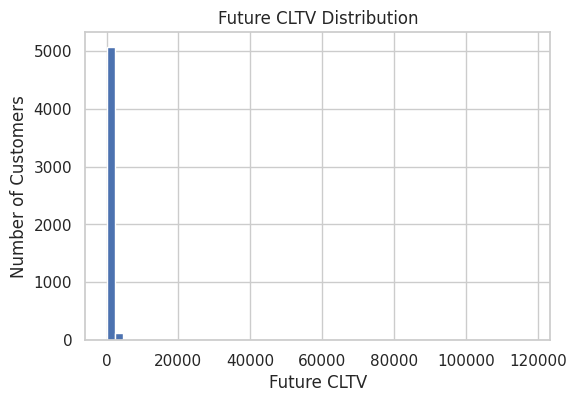

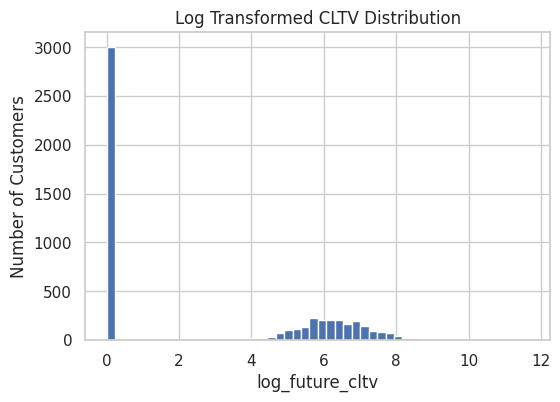


Train shape: (4196, 6)
Test shape: (1049, 6)

Linear Regression Performance
MAE : 1288.0
RMSE: 26841.63
R2  : -59.25

Model Comparison
               Model          MAE          RMSE         R2
1      Random Forest   426.259311   2916.759721   0.288561
2  Gradient Boosting   414.293834   2946.091931   0.274180
0  Linear Regression  1287.996812  26841.626612 -59.249580


In [ ]:
# ============================================================
# CLTV MODELING PIPELINE
# 1. Explore CLTV distribution
# 2. Log transform target
# 3. Train baseline model
# 4. Compare Random Forest vs Gradient Boosting
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Create the CLTV dataset --- START
# Define the snapshot date for the observation window
observation_snapshot_date = observation_df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Add the 'Revenue' column to observation_df as it was created before this column was defined on df.
# This ensures observation_df has the necessary 'Revenue' column for aggregation.
observation_df["Revenue"] = observation_df["Quantity"] * observation_df["Price"]

# Calculate RFM features for the observation window
cltv_features = observation_df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda date: (observation_snapshot_date - date.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Unique_Products=('StockCode', 'nunique'),
    #Avg_Order_Value=('Revenue', lambda x: x.sum() / x.nunique() if x.nunique() > 0 else 0) # Calculate average order value from sales and number of invoices
    Avg_Order_Value=('Revenue', 'mean')
).reset_index()

# Merge with future_cltv to create the final cltv_dataset
cltv_dataset = pd.merge(cltv_features, future_cltv, on='Customer ID', how='left')
cltv_dataset["future_cltv"] = cltv_dataset["future_cltv"].fillna(0)
#cltv_dataset = pd.merge(cltv_features, future_cltv, on='Customer ID', how='inner')


# Handle potential zero monetary values if any customers had only refunds in observation_df
cltv_dataset = cltv_dataset[cltv_dataset['Monetary'] > 0]

print("CLTV Dataset (first 5 rows):")
display(cltv_dataset.head())
# --- Create the CLTV dataset --- END

# ------------------------------------------------------------
# STEP 1: EXPLORE CLTV DISTRIBUTION
# CLTV usually has a heavy right skew (few very large values)
# ------------------------------------------------------------

print("\nCLTV Summary Statistics")
print(cltv_dataset["future_cltv"].describe())

plt.figure(figsize=(6,4))
plt.hist(cltv_dataset["future_cltv"], bins=50)
plt.title("Future CLTV Distribution")
plt.xlabel("Future CLTV")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------------------------------------
# STEP 2: LOG TRANSFORM THE TARGET
# Helps stabilize variance and improves model performance
# ------------------------------------------------------------

cltv_dataset["log_future_cltv"] = np.log1p(cltv_dataset["future_cltv"])

plt.figure(figsize=(6,4))
plt.hist(cltv_dataset["log_future_cltv"], bins=50)
plt.title("Log Transformed CLTV Distribution")
plt.xlabel("log_future_cltv")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------------------------------------
# STEP 3: PREPARE FEATURES AND TARGET
# ------------------------------------------------------------

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Total_Quantity",
    "Unique_Products"
]

X = cltv_dataset[feature_cols]
y = cltv_dataset["log_future_cltv"]

# ------------------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------------------------
# STEP 4: TRAIN FIRST BASELINE MODEL (LINEAR REGRESSION)
# ------------------------------------------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

preds_log = linear_model.predict(X_test)

# Convert predictions back to original CLTV scale
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds_log)

mae = mean_absolute_error(y_test_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
r2 = r2_score(y_test_actual, preds_actual)

print("\nLinear Regression Performance")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2  :", round(r2,3))

# ------------------------------------------------------------
# STEP 5: RANDOM FOREST MODEL
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds_log = rf_model.predict(X_test)

rf_preds_actual = np.expm1(rf_preds_log)

rf_mae = mean_absolute_error(y_test_actual, rf_preds_actual)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_preds_actual))
rf_r2 = r2_score(y_test_actual, rf_preds_actual)

# ------------------------------------------------------------
# STEP 6: GRADIENT BOOSTING MODEL
# ------------------------------------------------------------

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds_log = gb_model.predict(X_test)

gb_preds_actual = np.expm1(gb_preds_log)

gb_mae = mean_absolute_error(y_test_actual, gb_preds_actual)
gb_rmse = np.sqrt(mean_squared_error(y_test_actual, gb_preds_actual))
gb_r2 = r2_score(y_test_actual, gb_preds_actual)

# ------------------------------------------------------------
# STEP 7: COMPARE MODELS
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, rf_mae, gb_mae],
    "RMSE": [rmse, rf_rmse, gb_rmse],
    "R2": [r2, rf_r2, gb_r2]
})

results = results.sort_values("RMSE")

print("\nModel Comparison")
print(results)


In [ ]:
# ============================================================
# CLTV - MORE POWERFUL BOOSTING MODELS
# Tries XGBoost and LightGBM and compares them with
# Random Forest and Gradient Boosting
# Assumes you already have:
#   X_train, X_test, y_train, y_test
# where y is log_future_cltv
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Uncomment this if running in Colab/Jupyter and packages are missing
# !pip install xgboost lightgbm -q

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ------------------------------------------------------------
# Helper function:
# Train model on log target, then convert predictions back to
# original CLTV scale for business-friendly evaluation
# ------------------------------------------------------------
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    # Train model
    model.fit(X_train, y_train)

    # Predict on log scale
    preds_log = model.predict(X_test)

    # Convert actual and predicted values back to original scale
    y_test_actual = np.expm1(y_test)
    preds_actual = np.expm1(preds_log)

    # Calculate regression metrics
    mae = mean_absolute_error(y_test_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    r2 = r2_score(y_test_actual, preds_actual)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# ------------------------------------------------------------
# Define models
# ------------------------------------------------------------

# Random Forest
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

# Gradient Boosting
gb_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# LightGBM
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# ------------------------------------------------------------
# Evaluate all models
# ------------------------------------------------------------
results = []

results.append(evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Gradient Boosting", gb_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("XGBoost", xgb_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("LightGBM", lgbm_model, X_train, X_test, y_train, y_test))

# ------------------------------------------------------------
# Create comparison table
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE").reset_index(drop=True)

print("\nModel Comparison")
print(results_df)

# ------------------------------------------------------------
# Optional: show best model clearly
# ------------------------------------------------------------
best_model = results_df.iloc[0]
print("\nBest Model Based on Lowest RMSE")
print(best_model)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000637 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1323
[LightGBM] [Info] Number of data points in the train set: 4196, number of used features: 6
[LightGBM] [Info] Start training from score 2.705378
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

Initial shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Shape after cleaning: (805549, 9)
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00

Observation shape: (633376, 9)
Prediction shape : (151993, 9)

Feature engineered dataset shap

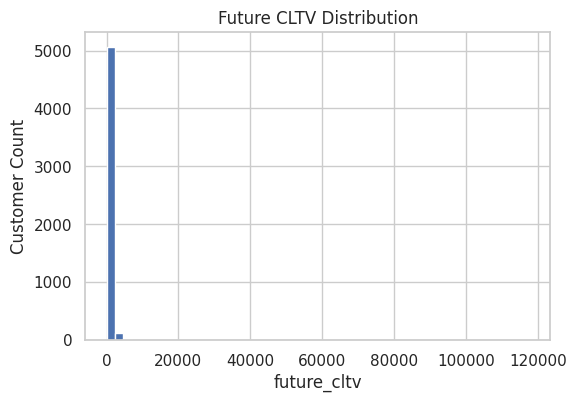

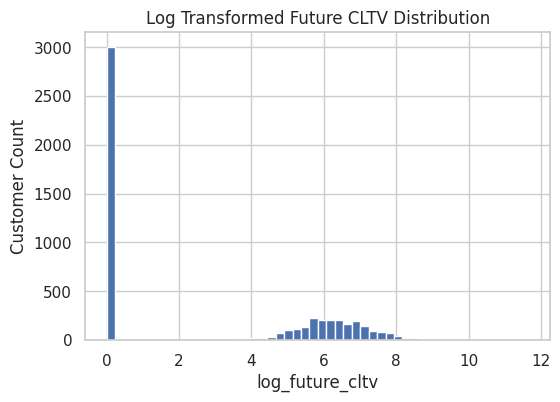


Train shape: (4196, 18)
Test shape : (1049, 18)

Model Comparison
               Model         MAE         RMSE        R2
0      Random Forest  414.765441  2789.006853  0.349518
1  Gradient Boosting  383.808229  2869.202481  0.311572
2  Linear Regression  505.813069  5526.585792 -1.554172

Best Model Based on Lowest RMSE
Model    Random Forest
MAE         414.765441
RMSE       2789.006853
R2            0.349518
Name: 0, dtype: object

Gradient Boosting Feature Importance
                Feature  Importance
15        Freq_Monetary    0.486430
0               Recency    0.225202
3        Total_Quantity    0.052212
4       Unique_Products    0.038246
2              Monetary    0.026569
14     Monthly_Monetary    0.023461
16    Recency_Frequency    0.023041
8      Avg_Purchase_Gap    0.022364
9   Revenue_Per_Product    0.016070
11     Revenue_Per_Unit    0.015033
5       Avg_Order_Value    0.014910
7     Purchase_Velocity    0.012826
13    Monthly_Frequency    0.011488
12        Months_Ac

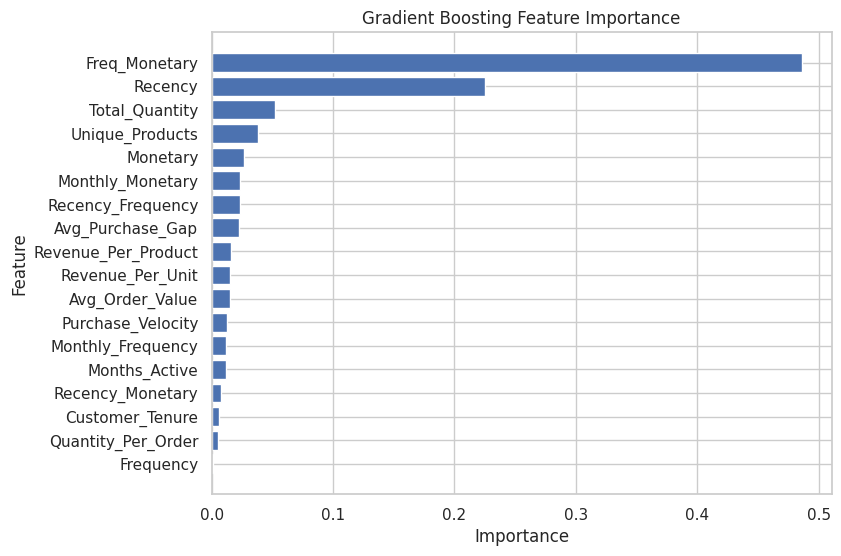


Saved: cltv_dataset_enhanced.csv


In [ ]:
 # ============================================================
# END-TO-END CLTV PREDICTION PIPELINE
# Raw Transactions -> Feature Engineering -> CLTV Model Comparison
# ============================================================

# ------------------------------------------------------------
# STEP 1: IMPORT LIBRARIES
# ------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

# ------------------------------------------------------------
# STEP 2: LOAD DATA
# Replace the file name if needed
# ------------------------------------------------------------
df = pd.read_csv("/content/drive/MyDrive/Online_Sales.csv", encoding="ISO-8859-1")

print("Initial shape:", df.shape)
print(df.head())

# ------------------------------------------------------------
# STEP 3: BASIC CLEANING
# Keep only valid customer transactions
# ------------------------------------------------------------
df = df[df["Customer ID"].notna()].copy()
df["Customer ID"] = df["Customer ID"].astype(str)

df = df[df["Quantity"] > 0].copy()
df = df[df["Price"] > 0].copy()

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["Price"]

print("\nShape after cleaning:", df.shape)
print("Date range:", df["InvoiceDate"].min(), "to", df["InvoiceDate"].max())

# ------------------------------------------------------------
# STEP 4: DEFINE OBSERVATION AND PREDICTION WINDOWS
# Observation: Dec 2010 -> Aug 2011
# Prediction : Sep 2011 -> Nov 2011
# ------------------------------------------------------------
observation_end = pd.to_datetime("2011-08-31")
prediction_start = pd.to_datetime("2011-09-01")
prediction_end = pd.to_datetime("2011-11-30")

observation_df = df[df["InvoiceDate"] <= observation_end].copy()
prediction_df = df[
    (df["InvoiceDate"] >= prediction_start) &
    (df["InvoiceDate"] <= prediction_end)
].copy()

print("\nObservation shape:", observation_df.shape)
print("Prediction shape :", prediction_df.shape)

# ------------------------------------------------------------
# STEP 5: CREATE CUSTOMER FEATURES FROM OBSERVATION WINDOW
# THIS IS WHERE RFM + FEATURE ENGINEERING BELONGS
# ------------------------------------------------------------
snapshot_date = observation_end + pd.Timedelta(days=1)

customer_features = observation_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Unique_Products=("StockCode", "nunique"),
    First_Purchase_Date=("InvoiceDate", "min"),
    Last_Purchase_Date=("InvoiceDate", "max")
).reset_index()

# -----------------------------
# BASIC DERIVED FEATURES
# -----------------------------
customer_features["Avg_Order_Value"] = (
    customer_features["Monetary"] / customer_features["Frequency"]
)

customer_features["Customer_Tenure"] = (
    customer_features["Last_Purchase_Date"] - customer_features["First_Purchase_Date"]
).dt.days

# Prevent divide-by-zero for same-day customers
customer_features["Customer_Tenure"] = customer_features["Customer_Tenure"].replace(0, 1)

customer_features["Purchase_Velocity"] = (
    customer_features["Frequency"] / customer_features["Customer_Tenure"]
)

customer_features["Avg_Purchase_Gap"] = (
    customer_features["Customer_Tenure"] / customer_features["Frequency"]
)

customer_features["Revenue_Per_Product"] = (
    customer_features["Monetary"] / customer_features["Unique_Products"]
)

customer_features["Quantity_Per_Order"] = (
    customer_features["Total_Quantity"] / customer_features["Frequency"]
)

customer_features["Revenue_Per_Unit"] = (
    customer_features["Monetary"] / customer_features["Total_Quantity"]
)

# -----------------------------
# MONTHLY BEHAVIOR FEATURES
# -----------------------------
customer_features["Months_Active"] = customer_features["Customer_Tenure"] / 30.0
customer_features["Months_Active"] = customer_features["Months_Active"].replace(0, 1/30)

customer_features["Monthly_Frequency"] = (
    customer_features["Frequency"] / customer_features["Months_Active"]
)

customer_features["Monthly_Monetary"] = (
    customer_features["Monetary"] / customer_features["Months_Active"]
)

# -----------------------------
# INTERACTION FEATURES
# -----------------------------
customer_features["Freq_Monetary"] = (
    customer_features["Frequency"] * customer_features["Monetary"]
)

customer_features["Recency_Frequency"] = (
    customer_features["Recency"] * customer_features["Frequency"]
)

customer_features["Recency_Monetary"] = (
    customer_features["Recency"] * customer_features["Monetary"]
)

# Safe cleanup
customer_features = customer_features.replace([np.inf, -np.inf], np.nan)
num_cols = customer_features.select_dtypes(include=[np.number]).columns
customer_features[num_cols] = customer_features[num_cols].fillna(0)

# Drop raw dates before modeling
feature_engineered_df = customer_features.drop(
    columns=["First_Purchase_Date", "Last_Purchase_Date"]
)

print("\nFeature engineered dataset shape:", feature_engineered_df.shape)
print(feature_engineered_df.head())

# ------------------------------------------------------------
# STEP 6: CREATE FUTURE CLTV TARGET FROM PREDICTION WINDOW
# ------------------------------------------------------------
future_cltv = (
    prediction_df.groupby("Customer ID")
    .agg(future_cltv=("Revenue", "sum"))
    .reset_index()
)

print("\nFuture CLTV shape:", future_cltv.shape)
print(future_cltv.head())

# ------------------------------------------------------------
# STEP 7: MERGE FEATURES + TARGET
# Customers with no future purchases get 0 CLTV
# ------------------------------------------------------------
cltv_dataset = feature_engineered_df.merge(
    future_cltv,
    on="Customer ID",
    how="left"
)

cltv_dataset["future_cltv"] = cltv_dataset["future_cltv"].fillna(0)

print("\nFinal CLTV dataset shape:", cltv_dataset.shape)
print(cltv_dataset.head())

# ------------------------------------------------------------
# STEP 8: EXPLORE CLTV DISTRIBUTION
# ------------------------------------------------------------
print("\nFuture CLTV Summary Statistics")
print(cltv_dataset["future_cltv"].describe())

plt.figure(figsize=(6, 4))
plt.hist(cltv_dataset["future_cltv"], bins=50)
plt.title("Future CLTV Distribution")
plt.xlabel("future_cltv")
plt.ylabel("Customer Count")
plt.show()

# ------------------------------------------------------------
# STEP 9: LOG TRANSFORM TARGET
# ------------------------------------------------------------
cltv_dataset["log_future_cltv"] = np.log1p(cltv_dataset["future_cltv"])

plt.figure(figsize=(6, 4))
plt.hist(cltv_dataset["log_future_cltv"], bins=50)
plt.title("Log Transformed Future CLTV Distribution")
plt.xlabel("log_future_cltv")
plt.ylabel("Customer Count")
plt.show()

# ------------------------------------------------------------
# STEP 10: DEFINE FEATURES AND TARGET
# ------------------------------------------------------------
feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Total_Quantity",
    "Unique_Products",
    "Avg_Order_Value",
    "Customer_Tenure",
    "Purchase_Velocity",
    "Avg_Purchase_Gap",
    "Revenue_Per_Product",
    "Quantity_Per_Order",
    "Revenue_Per_Unit",
    "Months_Active",
    "Monthly_Frequency",
    "Monthly_Monetary",
    "Freq_Monetary",
    "Recency_Frequency",
    "Recency_Monetary"
]

X = cltv_dataset[feature_cols]
y = cltv_dataset["log_future_cltv"]

# ------------------------------------------------------------
# STEP 11: TRAIN-TEST SPLIT
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# STEP 12: HELPER FUNCTION FOR MODEL EVALUATION
# Metrics are computed on original CLTV scale
# ------------------------------------------------------------
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    preds_log = model.predict(X_test)

    y_test_actual = np.expm1(y_test)
    preds_actual = np.expm1(preds_log)

    mae = mean_absolute_error(y_test_actual, preds_actual)
    rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
    r2 = r2_score(y_test_actual, preds_actual)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# ------------------------------------------------------------
# STEP 13: TRAIN MODELS
# ------------------------------------------------------------
linear_model = LinearRegression()

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

# ------------------------------------------------------------
# STEP 14: EVALUATE MODELS
# ------------------------------------------------------------
results = []
results.append(evaluate_model("Linear Regression", linear_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Random Forest", rf_model, X_train, X_test, y_train, y_test))
results.append(evaluate_model("Gradient Boosting", gb_model, X_train, X_test, y_train, y_test))

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

print("\nModel Comparison")
print(results_df)

print("\nBest Model Based on Lowest RMSE")
print(results_df.iloc[0])

# ------------------------------------------------------------
# STEP 15: FEATURE IMPORTANCE FOR BEST TREE MODEL
# ------------------------------------------------------------
gb_model.fit(X_train, y_train)
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gb_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nGradient Boosting Feature Importance")
print(importance_df)

plt.figure(figsize=(8, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Gradient Boosting Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# ------------------------------------------------------------
# STEP 16: OPTIONAL - SAVE FINAL DATASET
# ------------------------------------------------------------
cltv_dataset.to_csv("cltv_dataset_enhanced.csv", index=False)
print("\nSaved: cltv_dataset_enhanced.csv")

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_tuned = RandomForestRegressor(
    n_estimators=800,
    max_depth=15,
    min_samples_leaf=2,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(X_train, y_train)

preds_log = rf_tuned.predict(X_test)

y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds_log)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
r2 = r2_score(y_test_actual, preds_actual)

print("Tuned Random Forest")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

Tuned Random Forest
MAE: 415.0070855981345
RMSE: 2736.5769884314677
R2: 0.3737442847232907


# ***Final CLTV Model and values***

CLTV Dataset (first 5 rows):


,Customer ID,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,Tenure,Purchase_Frequency,Avg_Order_Value,future_cltv
0,12346.0,225,12,77556.46,74285,27,400,0.029925,6463.038333,0.00
1,12347.0,29,6,4114.18,2418,107,274,0.021818,685.696667,1294.32
2,12348.0,148,4,1709.40,2497,25,189,0.021053,427.350000,310.00
3,12349.0,307,3,2671.14,993,90,181,0.016484,890.380000,1757.55
4,12350.0,210,1,334.40,197,17,0,1.000000,334.400000,0.00



CLTV Dataset shape: (5245, 10)
Customers with zero future CLTV: 3007
Customers with non-zero future CLTV: 2238

CLTV Summary Statistics
count      5245.000000
mean        523.756143
std        3139.922073
min           0.000000
25%           0.000000
50%           0.000000
75%         426.600000
max      117634.530000
Name: future_cltv, dtype: float64


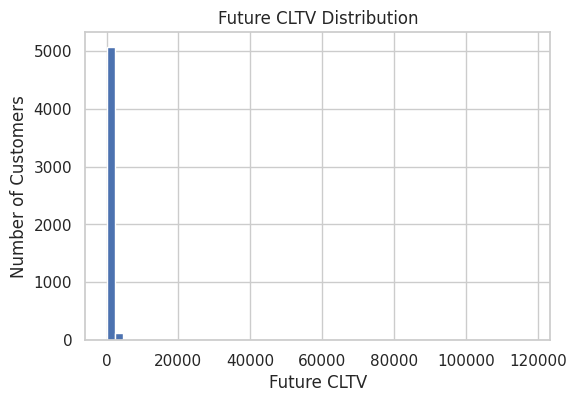

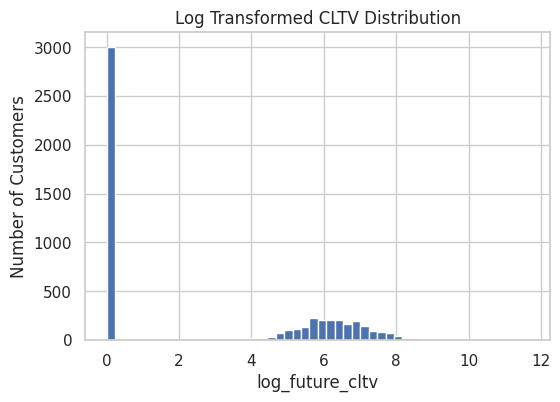


Feature Columns Used:
['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Total_Quantity', 'Unique_Products', 'Tenure', 'Purchase_Frequency']

Train shape: (4196, 8)
Test shape: (1049, 8)

Linear Regression Performance
MAE : 610.77
RMSE: 5969.98
R2  : -1.98

Random Forest Performance
MAE : 415.9
RMSE: 2819.27
R2  : 0.335

Gradient Boosting Performance
MAE : 381.21
RMSE: 2550.64
R2  : 0.456

Model Comparison
               Model         MAE         RMSE        R2
0  Gradient Boosting  381.214116  2550.642030  0.455954
1      Random Forest  415.899294  2819.270818  0.335324
2  Linear Regression  610.774696  5969.980646 -1.980453

Best Model Based on Lowest RMSE
Model    Gradient Boosting
MAE             381.214116
RMSE            2550.64203
R2                0.455954
Name: 0, dtype: object


In [ ]:
# ============================================================
# CLTV MODELING PIPELINE
# 1. Explore CLTV distribution
# 2. Log transform target
# 3. Train baseline model
# 4. Compare Random Forest vs Gradient Boosting
# 5. Add stronger behavioral features
#    - Tenure
#    - Purchase_Frequency
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ============================================================
# --- Create the CLTV dataset --- START
# ============================================================

# Define the snapshot date for the observation window
observation_snapshot_date = observation_df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Ensure Revenue exists in both datasets
observation_df = observation_df.copy()
prediction_df = prediction_df.copy()

observation_df["Revenue"] = observation_df["Quantity"] * observation_df["Price"]
prediction_df["Revenue"] = prediction_df["Quantity"] * prediction_df["Price"]

# ------------------------------------------------------------
# Create future CLTV target from prediction window
# ------------------------------------------------------------
future_cltv = (
    prediction_df.groupby("Customer ID")
    .agg(future_cltv=("Revenue", "sum"))
    .reset_index()
)

# ------------------------------------------------------------
# Build base customer features from observation window
# ------------------------------------------------------------
cltv_features = observation_df.groupby("Customer ID").agg(
    Recency=("InvoiceDate", lambda x: (observation_snapshot_date - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Unique_Products=("StockCode", "nunique"),
    First_Purchase_Date=("InvoiceDate", "min"),
    Last_Purchase_Date=("InvoiceDate", "max")
).reset_index()

# ------------------------------------------------------------
# Additional feature 1: Tenure
# ------------------------------------------------------------
cltv_features["Tenure"] = (
    cltv_features["Last_Purchase_Date"] - cltv_features["First_Purchase_Date"]
).dt.days

# ------------------------------------------------------------
# Additional feature 2: Purchase Frequency
# Frequency normalized by tenure
# +1 avoids division by zero for very new customers
# ------------------------------------------------------------
cltv_features["Purchase_Frequency"] = (
    cltv_features["Frequency"] / (cltv_features["Tenure"] + 1)
)

# ------------------------------------------------------------
# Correct Avg_Order_Value
# ------------------------------------------------------------
cltv_features["Avg_Order_Value"] = (
    cltv_features["Monetary"] / cltv_features["Frequency"]
)

# ------------------------------------------------------------
# Drop helper date columns after feature creation
# ------------------------------------------------------------
cltv_features = cltv_features.drop(columns=["First_Purchase_Date", "Last_Purchase_Date"])

# ------------------------------------------------------------
# Merge with future_cltv using LEFT JOIN
# Keep all customers from observation period
# Customers with no future purchase get future_cltv = 0
# ------------------------------------------------------------
cltv_dataset = pd.merge(
    cltv_features,
    future_cltv,
    on="Customer ID",
    how="left"
)

cltv_dataset["future_cltv"] = cltv_dataset["future_cltv"].fillna(0)

# Safety filter
cltv_dataset = cltv_dataset[cltv_dataset["Monetary"] > 0].copy()

print("CLTV Dataset (first 5 rows):")
display(cltv_dataset.head())

print("\nCLTV Dataset shape:", cltv_dataset.shape)
print("Customers with zero future CLTV:", (cltv_dataset["future_cltv"] == 0).sum())
print("Customers with non-zero future CLTV:", (cltv_dataset["future_cltv"] > 0).sum())

# ============================================================
# --- Create the CLTV dataset --- END
# ============================================================

# ------------------------------------------------------------
# STEP 1: EXPLORE CLTV DISTRIBUTION
# ------------------------------------------------------------

print("\nCLTV Summary Statistics")
print(cltv_dataset["future_cltv"].describe())

plt.figure(figsize=(6,4))
plt.hist(cltv_dataset["future_cltv"], bins=50)
plt.title("Future CLTV Distribution")
plt.xlabel("Future CLTV")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------------------------------------
# STEP 2: LOG TRANSFORM THE TARGET
# ------------------------------------------------------------

cltv_dataset["log_future_cltv"] = np.log1p(cltv_dataset["future_cltv"])

plt.figure(figsize=(6,4))
plt.hist(cltv_dataset["log_future_cltv"], bins=50)
plt.title("Log Transformed CLTV Distribution")
plt.xlabel("log_future_cltv")
plt.ylabel("Number of Customers")
plt.show()

# ------------------------------------------------------------
# STEP 3: PREPARE FEATURES AND TARGET
# ------------------------------------------------------------

feature_cols = [
    "Recency",
    "Frequency",
    "Monetary",
    "Avg_Order_Value",
    "Total_Quantity",
    "Unique_Products",
    "Tenure",
    "Purchase_Frequency"
]

X = cltv_dataset[feature_cols]
y = cltv_dataset["log_future_cltv"]

print("\nFeature Columns Used:")
print(feature_cols)

# ------------------------------------------------------------
# TRAIN TEST SPLIT
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ------------------------------------------------------------
# STEP 4: TRAIN BASELINE MODEL (LINEAR REGRESSION)
# ------------------------------------------------------------

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

preds_log = linear_model.predict(X_test)

# Convert predictions back to original CLTV scale
y_test_actual = np.expm1(y_test)
preds_actual = np.expm1(preds_log)

mae = mean_absolute_error(y_test_actual, preds_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))
r2 = r2_score(y_test_actual, preds_actual)

print("\nLinear Regression Performance")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2  :", round(r2, 3))

# ------------------------------------------------------------
# STEP 5: RANDOM FOREST MODEL
# ------------------------------------------------------------

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_preds_log = rf_model.predict(X_test)
rf_preds_actual = np.expm1(rf_preds_log)

rf_mae = mean_absolute_error(y_test_actual, rf_preds_actual)
rf_rmse = np.sqrt(mean_squared_error(y_test_actual, rf_preds_actual))
rf_r2 = r2_score(y_test_actual, rf_preds_actual)

print("\nRandom Forest Performance")
print("MAE :", round(rf_mae, 2))
print("RMSE:", round(rf_rmse, 2))
print("R2  :", round(rf_r2, 3))

# ------------------------------------------------------------
# STEP 6: GRADIENT BOOSTING MODEL
# ------------------------------------------------------------

gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

gb_preds_log = gb_model.predict(X_test)
gb_preds_actual = np.expm1(gb_preds_log)

gb_mae = mean_absolute_error(y_test_actual, gb_preds_actual)
gb_rmse = np.sqrt(mean_squared_error(y_test_actual, gb_preds_actual))
gb_r2 = r2_score(y_test_actual, gb_preds_actual)

print("\nGradient Boosting Performance")
print("MAE :", round(gb_mae, 2))
print("RMSE:", round(gb_rmse, 2))
print("R2  :", round(gb_r2, 3))

# ------------------------------------------------------------
# STEP 7: COMPARE MODELS
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae, rf_mae, gb_mae],
    "RMSE": [rmse, rf_rmse, gb_rmse],
    "R2": [r2, rf_r2, gb_r2]
})

results = results.sort_values("RMSE").reset_index(drop=True)

print("\nModel Comparison")
print(results)

# ------------------------------------------------------------
# Optional: show best model clearly
# ------------------------------------------------------------
best_model = results.iloc[0]
print("\nBest Model Based on Lowest RMSE")
print(best_model)


CLTV MODEL VALIDATION SUMMARY

1. Dataset Shape
Total CLTV records: 5245
Total features used: 27
Train shape: (4196, 27)
Test shape : (1049, 27)

2. Future CLTV Target Validation
Minimum future CLTV: 0.0
Maximum future CLTV: 117634.53
Customers with zero future CLTV: 3007
Customers with non-zero future CLTV: 2238

3. Missing Value Check
Recency                   0
Frequency                 0
Monetary                  0
Total_Quantity            0
Unique_Products           0
Avg_Order_Value           0
Median_Order_Value        0
Max_Order_Value           0
Std_Order_Value           0
Tenure                    0
Purchase_Frequency        0
Avg_Purchase_Gap          0
Revenue_Per_Product       0
Quantity_Per_Order        0
Revenue_Per_Unit          0
Recent_90D_Revenue        0
Recent_90D_Quantity       0
Recent_90D_Orders         0
Recent_30D_Revenue        0
Recent_30D_Quantity       0
Recent_30D_Orders         0
Repeat_Product_Ratio      0
Max_Product_Dependency    0
Recency_Frequency

,Actual_CLTV,Predicted_CLTV,Absolute_Error
1858,0.00,0.789647,0.789647
3541,677.86,85.252452,592.607548
1128,0.00,42.428535,42.428535
4783,271.20,1.336305,269.863695
931,1269.10,13.965976,1255.134024
8,0.00,5.739756,5.739756
5019,0.00,5.706296,5.706296
23,739.28,60.232160,679.047840
4757,1720.58,146.181318,1574.398682
1611,0.00,2.306751,2.306751



7. Prediction Error Summary
count     1049.000000
mean       389.653030
std       2855.715005
min          0.007197
25%          2.937945
50%         26.268842
75%        344.238308
max      90087.080760
Name: Absolute_Error, dtype: float64


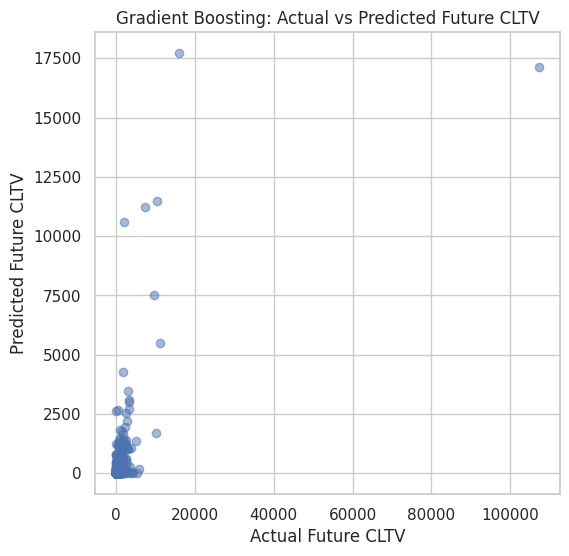


8. Gradient Boosting Feature Importance


,Feature,Importance
26,Recency_Monetary_Ratio,0.500471
24,Frequency_Monetary,0.096814
16,Recent_90D_Quantity,0.053290
0,Recency,0.049163
15,Recent_90D_Revenue,0.042490
25,Monetary_Per_Tenure,0.025697
10,Purchase_Frequency,0.025252
4,Unique_Products,0.020022
23,Recency_Frequency,0.018892
21,Repeat_Product_Ratio,0.018599


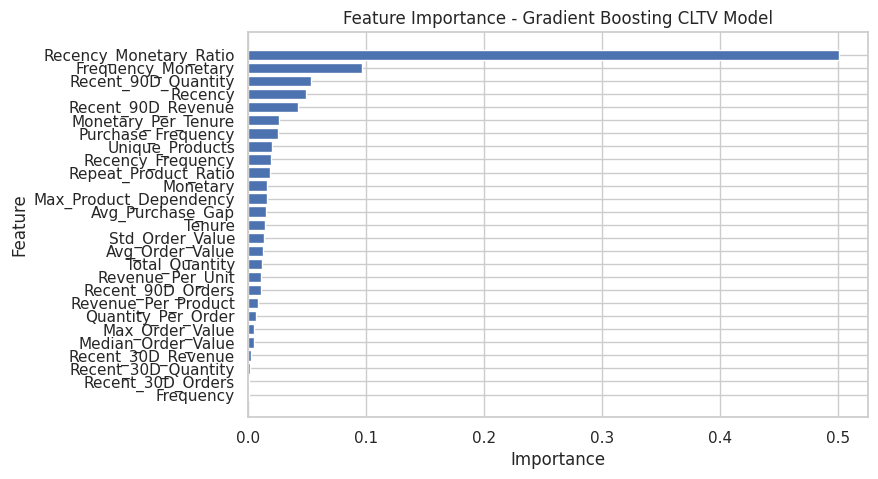


CLTV MODEL VALIDATION COMPLETE


In [ ]:
# ============================================================
# CLTV MODEL VALIDATION BLOCK
# Final Model: Gradient Boosting Regressor
# ============================================================

print("="*70)
print("CLTV MODEL VALIDATION SUMMARY")
print("="*70)

# ------------------------------------------------------------
# 1. Dataset Shape Validation
# ------------------------------------------------------------
print("\n1. Dataset Shape")
print("Total CLTV records:", cltv_dataset.shape[0])
print("Total features used:", len(feature_cols))
print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

# ------------------------------------------------------------
# 2. Target Validation
# ------------------------------------------------------------
print("\n2. Future CLTV Target Validation")
print("Minimum future CLTV:", cltv_dataset["future_cltv"].min())
print("Maximum future CLTV:", cltv_dataset["future_cltv"].max())
print("Customers with zero future CLTV:",
      (cltv_dataset["future_cltv"] == 0).sum())
print("Customers with non-zero future CLTV:",
      (cltv_dataset["future_cltv"] > 0).sum())

# ------------------------------------------------------------
# 3. Missing Value Validation
# ------------------------------------------------------------
print("\n3. Missing Value Check")
print(cltv_dataset[feature_cols + ["future_cltv", "log_future_cltv"]].isnull().sum())

# ------------------------------------------------------------
# 4. Feature Validation
# ------------------------------------------------------------
print("\n4. Feature Columns Used")
for col in feature_cols:
    print("-", col)

# ------------------------------------------------------------
# 5. Final Model Performance Validation
# ------------------------------------------------------------
print("\n5. Final Model Performance: Gradient Boosting")

final_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

final_model.fit(X_train, y_train)

final_preds_log = final_model.predict(X_test)
final_preds_actual = np.expm1(final_preds_log)
y_test_actual = np.expm1(y_test)

final_mae = mean_absolute_error(y_test_actual, final_preds_actual)
final_rmse = np.sqrt(mean_squared_error(y_test_actual, final_preds_actual))
final_r2 = r2_score(y_test_actual, final_preds_actual)

print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R2  :", round(final_r2, 3))

# ------------------------------------------------------------
# 6. Actual vs Predicted Sample
# ------------------------------------------------------------
validation_results = pd.DataFrame({
    "Actual_CLTV": y_test_actual,
    "Predicted_CLTV": final_preds_actual,
    "Absolute_Error": abs(y_test_actual - final_preds_actual)
})

print("\n6. Actual vs Predicted CLTV Sample")
display(validation_results.head(10))

# ------------------------------------------------------------
# 7. Prediction Error Summary
# ------------------------------------------------------------
print("\n7. Prediction Error Summary")
print(validation_results["Absolute_Error"].describe())

# ------------------------------------------------------------
# 8. Actual vs Predicted Plot
# ------------------------------------------------------------
plt.figure(figsize=(6,6))
plt.scatter(validation_results["Actual_CLTV"],
            validation_results["Predicted_CLTV"],
            alpha=0.5)

plt.xlabel("Actual Future CLTV")
plt.ylabel("Predicted Future CLTV")
plt.title("Gradient Boosting: Actual vs Predicted Future CLTV")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# 9. Feature Importance
# ------------------------------------------------------------
importance_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": final_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\n8. Gradient Boosting Feature Importance")
display(importance_df)

plt.figure(figsize=(8,5))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Gradient Boosting CLTV Model")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

print("\n" + "="*70)
print("CLTV MODEL VALIDATION COMPLETE")
print("="*70)

# ***Final demand forecast valuest***###


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

value_model_v1 = XGBRegressor(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="reg:squarederror",
    random_state=42
)

value_model_v1.fit(X_train, yv_train)

pred_v1 = value_model_v1.predict(X_test)

print("Value Forecast V1 - Tuned XGBoost")
print("MAE:", mean_absolute_error(yv_test, pred_v1))
print("R2 :", r2_score(yv_test, pred_v1))

Value Forecast V1 - Tuned XGBoost
MAE: 1.672220793772814
R2 : 0.5927165986333239
